In [1]:
import numpy as np


class Board():
    def __init__(self):
        self.state = np.zeros((3,3))

    def valid_moves(self):
        return [(i, j) for j in range(3) for i in range(3) if self.state[i, j] == 0]

    def update(self, symbol, row, col):
        if self.state[row, col] == 0:
            self.state[row, col] = symbol
        else:
            raise ValueError ("movimiento ilegal !")

    def is_game_over(self):
        # comprobar filas y columnas
        if (self.state.sum(axis=0) == 3).sum() >= 1 or (self.state.sum(axis=1) == 3).sum() >= 1:
            return 1
        if (self.state.sum(axis=0) == -3).sum() >= 1 or (self.state.sum(axis=1) == -3).sum() >= 1:
            return -1
        # comprobar diagonales
        diag_sums = [
            sum([self.state[i, i] for i in range(3)]),
            sum([self.state[i, 3 - i - 1] for i in range(3)]),
        ]
        if diag_sums[0] == 3 or diag_sums[1] == 3:
            return 1
        if diag_sums[0] == -3 or diag_sums[1] == -3:
            return -1
        # empate
        if len(self.valid_moves()) == 0:
            return 0
        # seguir jugando
        return None

    def reset(self):
        self.state = np.zeros((3,3))

In [ ]:
from tqdm import tqdm


class Game():
    def __init__(self, player1, player2):
        player1.symbol = 1
        player2.symbol = -1
        self.players = [player1, player2]
        self.board = Board()

    def selfplay(self, rounds=100):
        wins = [0, 0]

        for i in tqdm(range(1, rounds + 1)):

            # Partidas impares → player1 primero / pares → player2 primero
            orden = self.players if i % 2 != 0 else list(reversed(self.players))

            self.board.reset()
            for player in self.players:
                player.reset()

            game_over = False
            while not game_over:
                for player in orden:
                    action = player.move(self.board)
                    self.board.update(player.symbol, action[0], action[1])
                    for p in self.players:
                        p.update(self.board)
                    if self.board.is_game_over() is not None:
                        game_over = True
                        break

            self.reward()
            for ix, player in enumerate(self.players):
                if self.board.is_game_over() == player.symbol:
                    wins[ix] += 1

        return wins
    
    def reward(self):
        winner = self.board.is_game_over()
        if winner == 0:
            for player in self.players:
                player.reward(0.5)
        else:
            for player in self.players:
                if winner == player.symbol:
                    player.reward(1)
                else:
                    player.reward(0)

In [ ]:
#Sin alternar turnos
from tqdm import tqdm

class Game():
    def __init__(self, player1, player2):
        player1.symbol = 1
        player2.symbol = -1
        self.players = [player1, player2]
        self.board = Board()

    def selfplay(self, rounds=100):
        wins = [0, 0]
        for i in tqdm(range(1, rounds + 1)):
            self.board.reset()
            for player in self.players:
                player.reset()
            game_over = False
            while not game_over:
                for player in self.players:
                    action = player.move(self.board)
                    self.board.update(player.symbol, action[0], action[1])
                    for player in self.players:
                        player.update(self.board)
                    if self.board.is_game_over() is not None:
                        game_over = True
                        break
            self.reward()
            for ix, player in enumerate(self.players):
                if self.board.is_game_over() == player.symbol:
                    wins[ix] += 1
        return wins


    def reward(self):
        winner = self.board.is_game_over()
        if winner == 0: # empate
            for player in self.players:
                player.reward(0.5)
        else: # le damos 1 recompensa al jugador que gana
            for player in self.players:
                if winner == player.symbol:
                    player.reward(1)
                else:
                    player.reward(0)

In [3]:
class Agent():
    def __init__(self, alpha=0.5, prob_exp=0.5):
        self.value_function = {} # tabla con pares estado -> valor
        self.alpha = alpha         # learning rate
        self.positions = []       # guardamos todas las posiciones de la partida
        self.prob_exp = prob_exp   # probabilidad de explorar

    def reset(self):
        self.positions = []

    def move(self, board, explore=True):
        valid_moves = board.valid_moves()
        # exploracion
        if explore and np.random.uniform(0, 1) < self.prob_exp:
            # vamos a una posición aleatoria
            ix = np.random.choice(len(valid_moves))
            return valid_moves[ix]
        # explotacion
        # vamos a la posición con más valor
        max_value = -1000
        for row, col in valid_moves:
            next_board = board.state.copy()
            next_board[row, col] = self.symbol
            next_state = str(next_board.reshape(3*3))
            value = 0 if self.value_function.get(next_state) is None else self.value_function.get(next_state)
            if value >= max_value:
                max_value = value
                best_row, best_col = row, col
        return best_row, best_col

    def update(self, board):
        self.positions.append(str(board.state.reshape(3*3)))


    def reward(self, reward):
        # al final de la partida (cuando recibimos la recompensa)
        # iteramos por tods los estados actualizando su valor en la tabla
        for p in reversed(self.positions):
            if self.value_function.get(p) is None:
                self.value_function[p] = 0
            self.value_function[p] += self.alpha * (reward - self.value_function[p])
            reward = self.value_function[p]

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [17]:
def dibujar_tablero(ax, estado, titulo='', resaltar=None):
    """
    Dibuja un tablero 3x3 en el eje `ax`.

    Parámetros
    ----------
    ax        : eje de matplotlib donde dibujar.
    estado    : np.ndarray de forma (3,3) con valores 0, 1 o -1.
    titulo    : texto que aparece sobre el tablero.
    resaltar  : tupla (fila, col) de la celda a resaltar, o None.
    """
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect('equal')
    ax.axis('off')

    # Fondo
    ax.add_patch(patches.Rectangle((0, 0), 3, 3, color='#fafafa', zorder=0))

    # Resaltar la celda del último movimiento
    if resaltar is not None:
        row, col = resaltar
        ax.add_patch(patches.Rectangle(
            (col, 2 - row), 1, 1,
            color='#fff3b0', zorder=1, linewidth=0
        ))

    # Líneas de la cuadrícula
    for k in [1, 2]:
        ax.axhline(k, color='#2c3e50', linewidth=2.5, zorder=2)
        ax.axvline(k, color='#2c3e50', linewidth=2.5, zorder=2)

    # Fichas
    for row in range(3):
        for col in range(3):
            v  = estado[row, col]
            cx = col + 0.5
            cy = 2.5 - row   # fila 0 arriba → cy más alto

            if v == 1:   # X – azul
                d = 0.27
                ax.plot([cx - d, cx + d], [cy - d, cy + d],
                        color='#2980b9', linewidth=5, solid_capstyle='round', zorder=3)
                ax.plot([cx - d, cx + d], [cy + d, cy - d],
                        color='#2980b9', linewidth=5, solid_capstyle='round', zorder=3)

            elif v == -1:  # O – rojo
                circ = plt.Circle((cx, cy), 0.27,
                                  fill=False, color='#e74c3c', linewidth=5, zorder=3)
                ax.add_patch(circ)

    if titulo:
        ax.set_title(titulo, fontsize=9, pad=5, fontweight='bold')


In [18]:
def visualizar_partida(agente1, agente2, explore=False):
    """
    Hace jugar a dos agentes entre sí y muestra todos los estados del tablero,
    desde el tablero vacío hasta el estado final.

    Parámetros
    ----------
    agente1 : Agent (juega con X, símbolo +1).
    agente2 : Agent (juega con O, símbolo -1).
    explore : si True, los agentes pueden explorar; si False, solo explotan.
    """
    board = Board()
    agente1.symbol = 1
    agente2.symbol = -1
    agente1.reset()
    agente2.reset()

    # Registrar el estado inicial y todos los movimientos
    snapshots = [(board.state.copy(), None, '— Inicio —')]
    jugadores  = [agente1, agente2]
    nombres    = ['X (agent1)', 'O (agent2)']
    turno      = 0

    while board.is_game_over() is None:
        jugador  = jugadores[turno % 2]
        nombre   = nombres[turno % 2]
        accion   = jugador.move(board, explore=explore)
        board.update(jugador.symbol, accion[0], accion[1])
        for p in jugadores:
            p.update(board)

        resultado = board.is_game_over()
        if resultado == 1:
            etiqueta = f'Movimiento {turno+1} ({nombre}) — ¡X gana!'
        elif resultado == -1:
            etiqueta = f'Movimiento {turno+1} ({nombre}) — ¡O gana!'
        elif resultado == 0:
            etiqueta = f'Movimiento {turno+1} ({nombre}) — Empate'
        else:
            etiqueta = f'Movimiento {turno+1} ({nombre})'

        snapshots.append((board.state.copy(), accion, etiqueta))
        turno += 1

    # ── Dibujar ──────────────────────────────────────────────────────────
    n  = len(snapshots)
    nc = min(n, 5)          # máximo 5 columnas por fila
    nr = (n + nc - 1) // nc

    fig, axes = plt.subplots(nr, nc, figsize=(3 * nc, 3.2 * nr))
    axes = np.array(axes).reshape(-1) if nr * nc > 1 else [axes]

    for idx, (estado, resaltar, titulo) in enumerate(snapshots):
        dibujar_tablero(axes[idx], estado, titulo=titulo, resaltar=resaltar)

    # Ocultar ejes sobrantes
    for idx in range(len(snapshots), len(axes)):
        axes[idx].axis('off')

    resultado_final = board.is_game_over()
    suptitulo = {1: '🏆 ¡Gana X (agent1)!', -1: '🏆 ¡Gana O (agent2)!', 0: '🤝 ¡Empate!'}
    fig.suptitle(suptitulo.get(resultado_final, ''), fontsize=13, fontweight='bold', y=1.01)

    plt.tight_layout()
    plt.show()
    return resultado_final


In [ ]:
#Probando con alternando turnos y solo 12k iteraciones
agent1 = Agent(alpha=0.1, prob_exp=0.5)
agent2 = Agent(alpha=0.1, prob_exp=0.5)

game = Game(agent1, agent2)

game.selfplay(12000)

100%|██████████| 12000/12000 [00:33<00:00, 357.33it/s]


[5665, 4909]

In [21]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[ 0. 1. -1. 0. 1. 0. 0. 1. -1.],1.0
1,[ 0. 0. 0. 1. 1. 1. 0. -1. -1.],1.0
2,[ 0. 0. -1. 1. 1. 1. 0. 0. -1.],1.0
3,[ 0. 0. 0. 1. 1. 1. -1. 0. -1.],1.0
4,[ 0. 1. 0. 0. 1. -1. 0. 1. -1.],1.0
...,...,...
6776,[-1. 1. 0. 0. -1. 0. -1. 1. 0.],0.0
6777,[-1. 1. 0. 1. -1. 1. -1. 1. 0.],0.0
6778,[-1. 0. -1. 1. -1. 1. 1. 1. -1.],0.0
6779,[ 1. 1. -1. 0. 0. 0. 1. -1. -1.],0.0


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


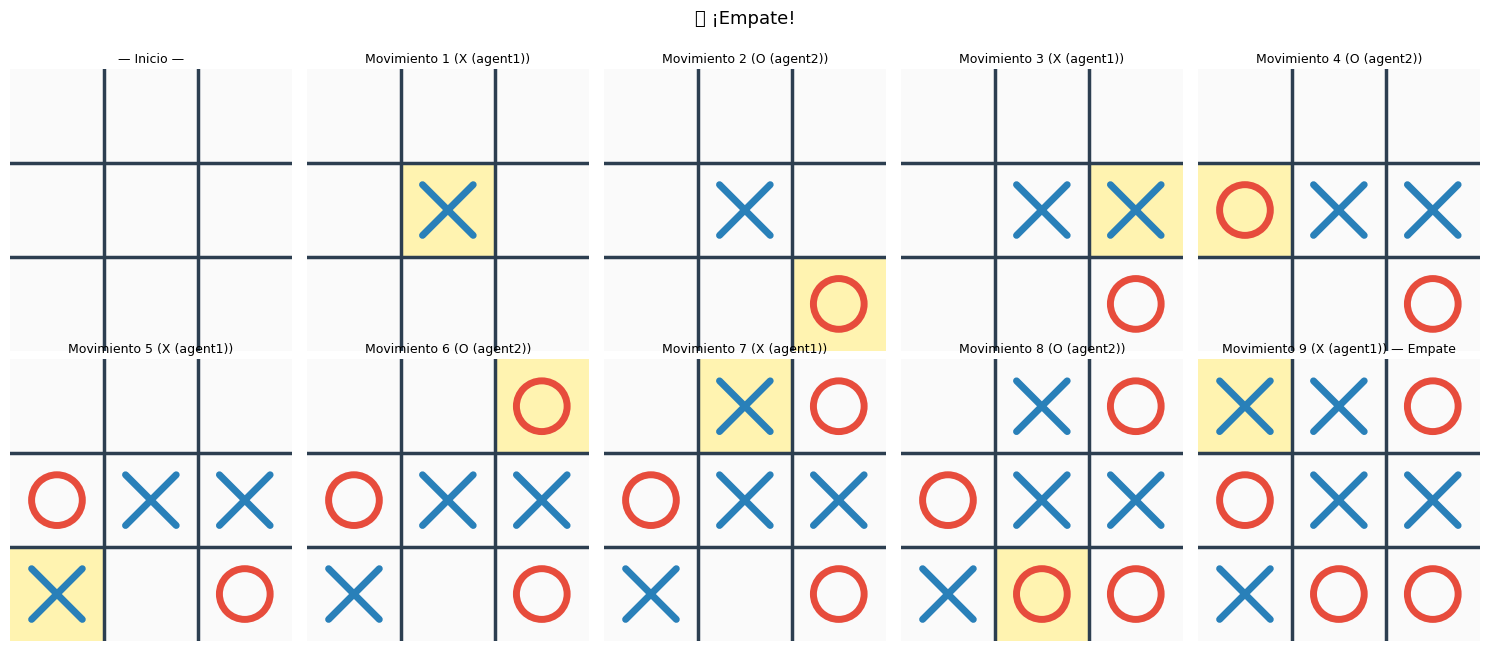

In [25]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

In [26]:
#Probando sin alternar turnos
agent1 = Agent(alpha=0.5, prob_exp=0.5)
agent2 = Agent(alpha=0.5, prob_exp=0.5)

game = Game(agent1, agent2)

game.selfplay(10000)

100%|██████████| 10000/10000 [00:18<00:00, 529.23it/s]


[4195, 4449]

In [27]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[ 0. 0. 0. 1. 1. 1. -1. 0. -1.],1.0
1,[ 0. 0. 1. 0. 1. -1. 1. 0. -1.],1.0
2,[ 0. 0. 1. 0. -1. 1. 0. -1. 1.],1.0
3,[ 0. 0. -1. 1. 1. 1. 0. 0. -1.],1.0
4,[-1. 0. -1. 1. 1. 1. 0. 0. 0.],1.0
...,...,...
6714,[ 1. 1. -1. -1. 1. 0. -1. -1. 0.],0.0
6715,[ 0. -1. 0. 1. -1. 1. -1. 0. 1.],0.0
6716,[ 0. -1. 0. 1. -1. 0. 1. -1. 1.],0.0
6717,[-1. 1. -1. 1. -1. 0. -1. 1. 1.],0.0


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


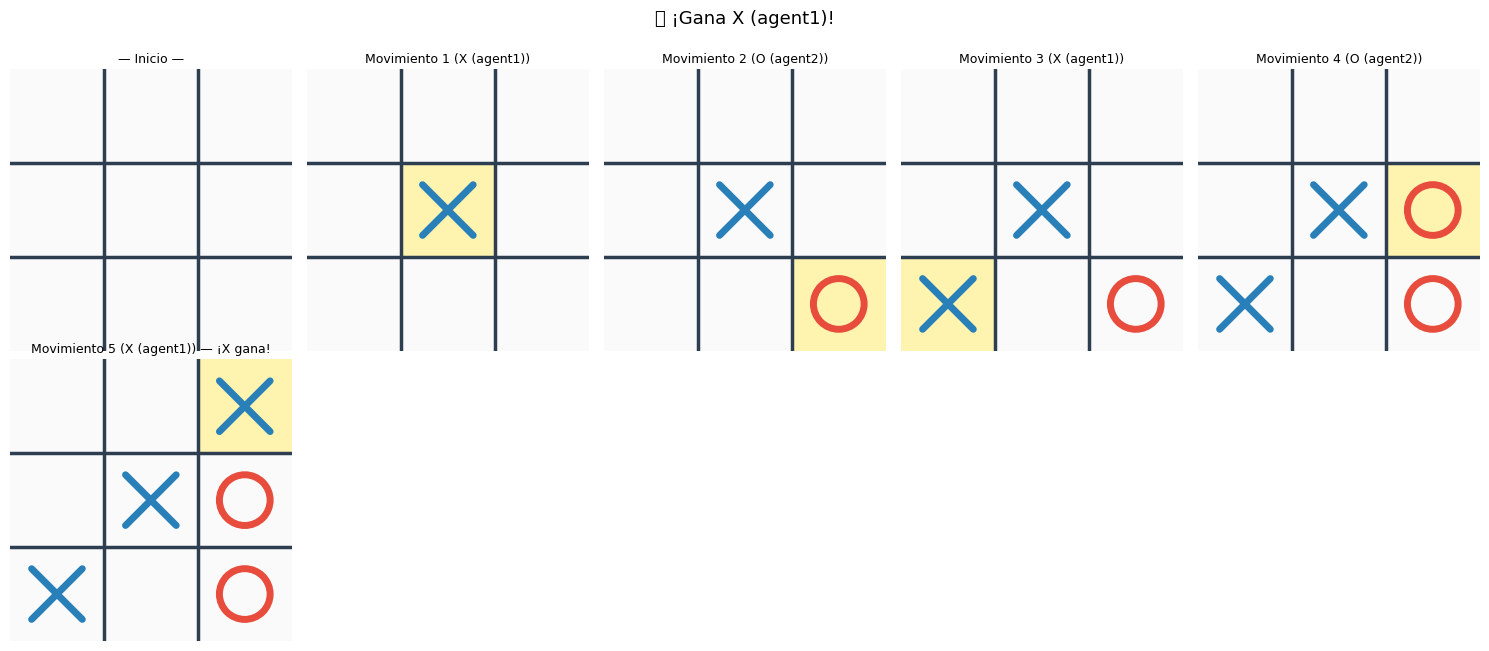

In [28]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


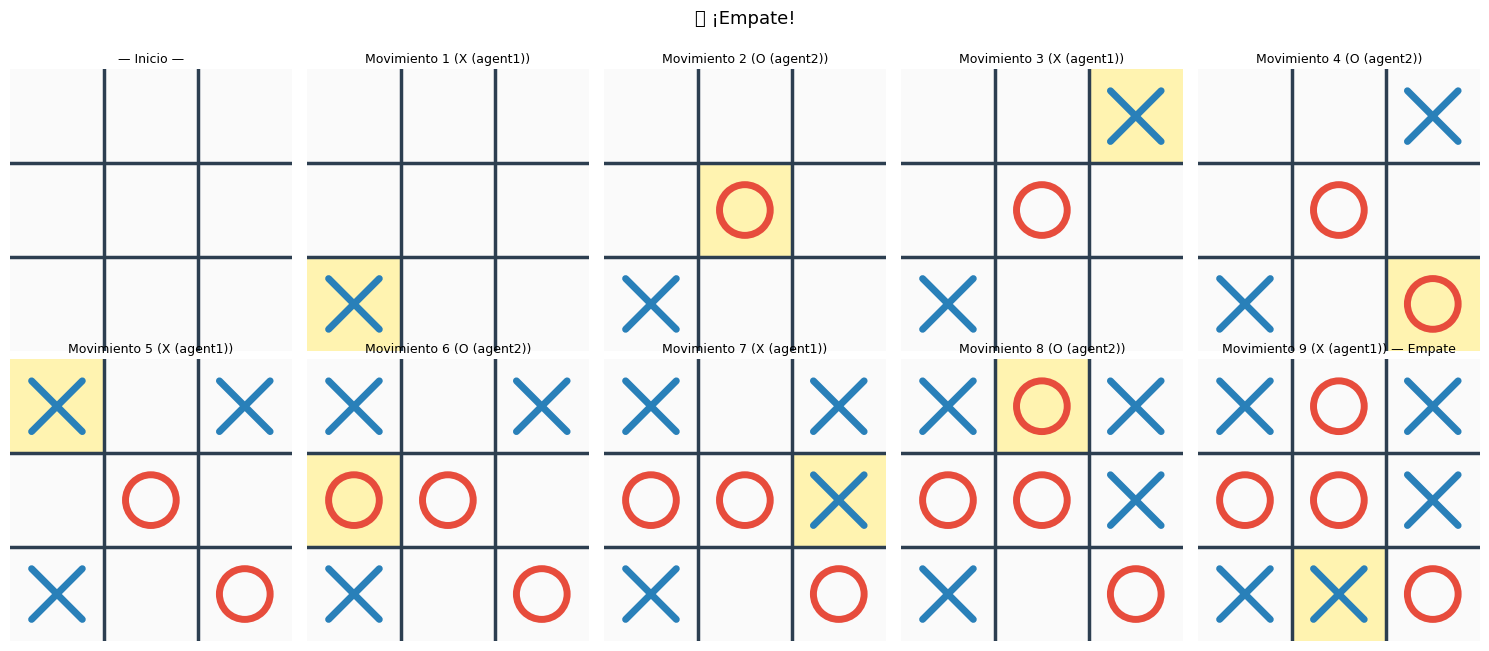

In [30]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


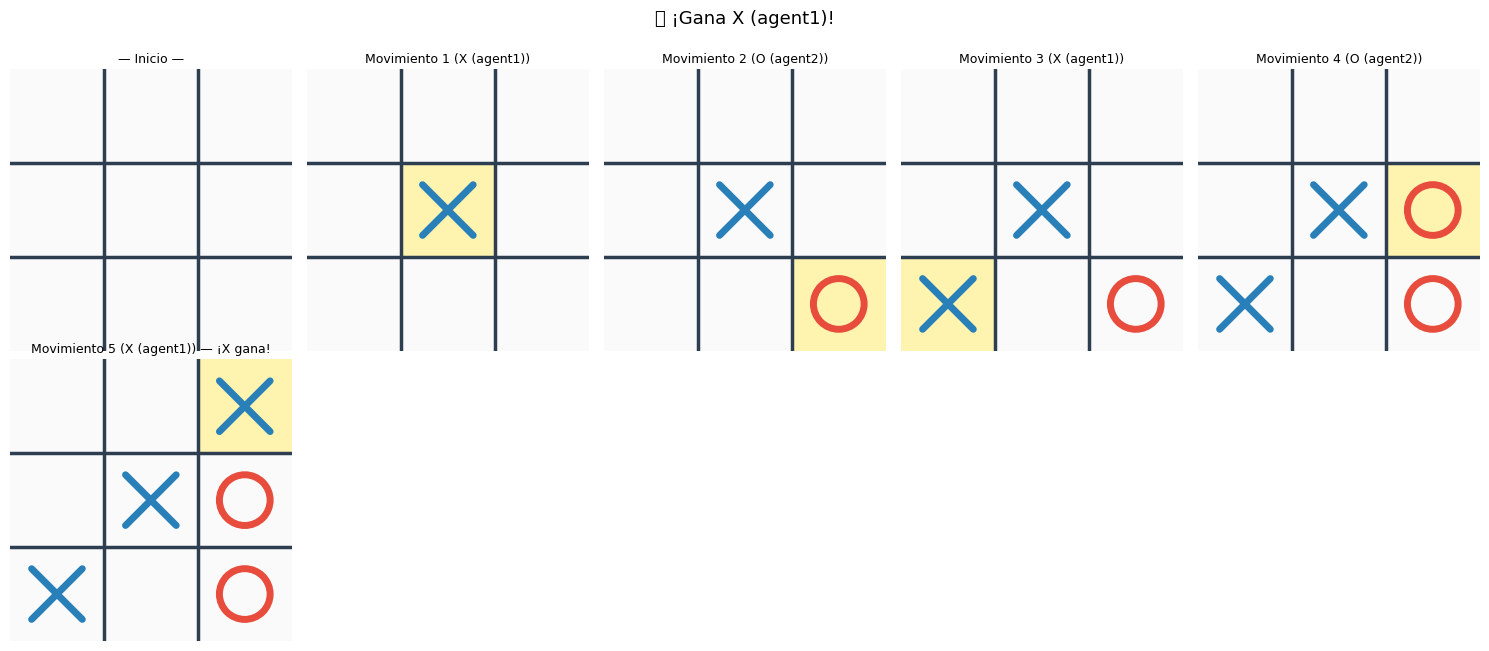

In [31]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

In [32]:
#Probando con alternando turnos y con alpha pequeña para que tome en cuenta muchisimo cada entrenamiento
agent1 = Agent(alpha=0.1, prob_exp=0.5)
agent2 = Agent(alpha=0.1, prob_exp=0.5)

game = Game(agent1, agent2)

game.selfplay(10000)

100%|██████████| 10000/10000 [00:17<00:00, 563.95it/s]


[4638, 4653]

In [33]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[-1. 0. -1. 0. 0. 0. 1. 1. 1.],1.000000
1,[ 0. -1. -1. 0. 0. 0. 1. 1. 1.],1.000000
2,[ 1. 0. -1. 0. 1. 0. -1. 0. 1.],1.000000
3,[ 1. -1. -1. 0. 1. 0. 0. 0. 1.],0.999998
4,[ 1. 0. -1. 0. 1. 0. 0. -1. 1.],0.999589
...,...,...
5518,[ 1. 0. 0. -1. 1. -1. 0. 1. -1.],0.000000
5519,[ 1. 0. 0. -1. 1. -1. 0. 1. 0.],0.000000
5520,[ 0. 1. -1. -1. -1. 1. -1. 1. 0.],0.000000
5521,[ 0. 1. -1. -1. -1. 1. 0. 1. 0.],0.000000


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


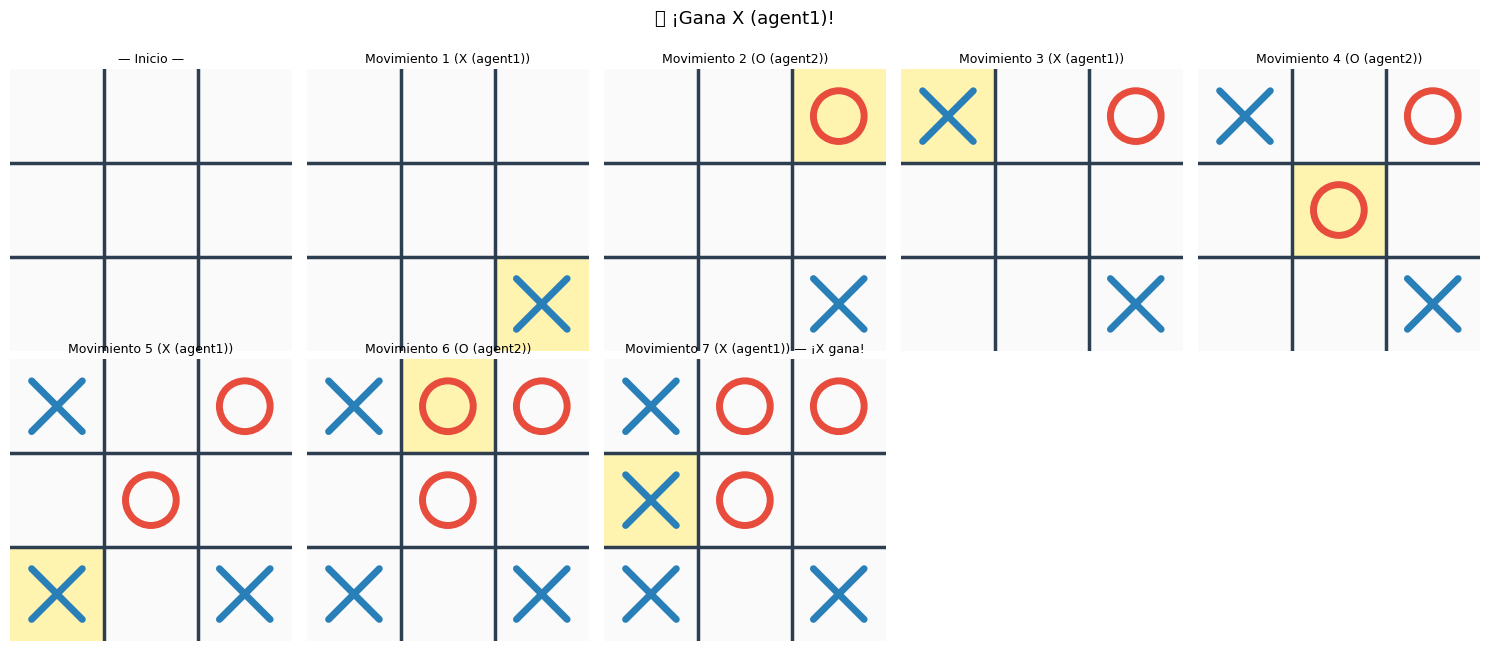

In [34]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


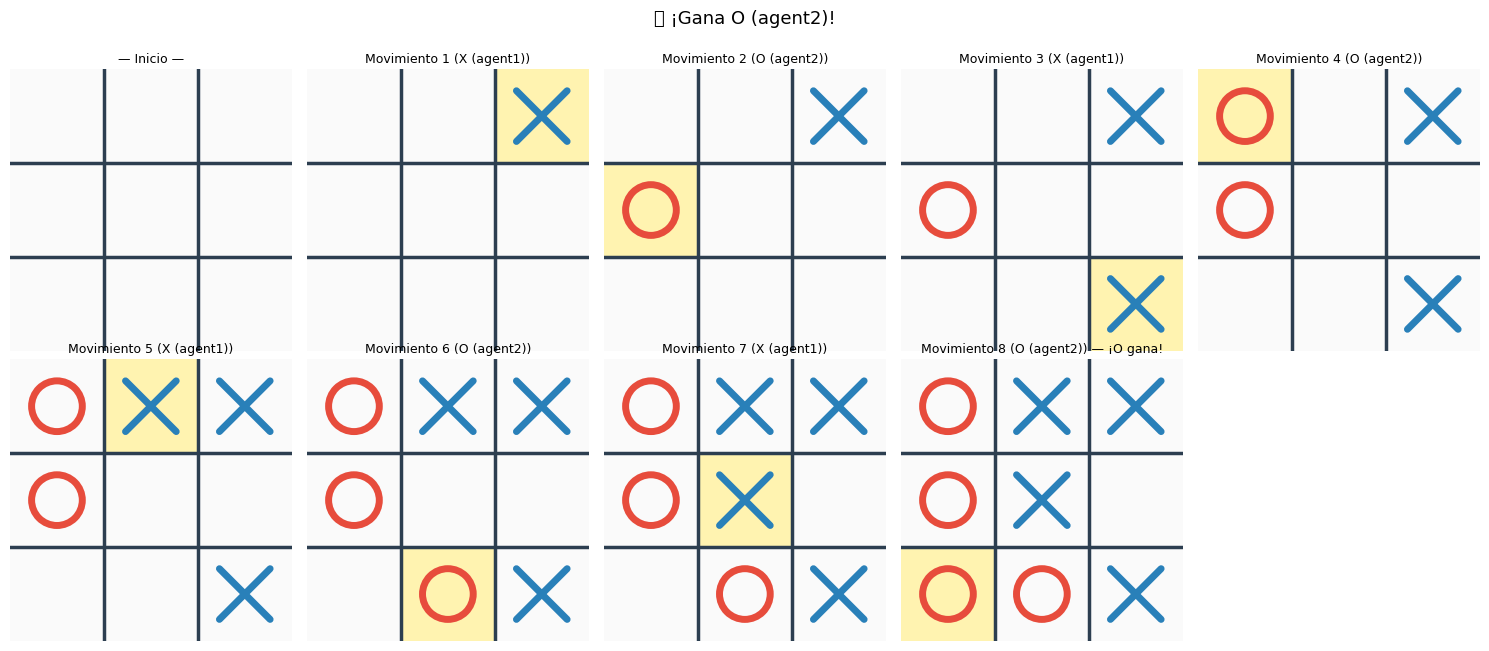

In [36]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

In [37]:
#Probando con alternando turnos y con alpha pequeña para que tome en cuenta muchisimo cada entrenamiento
agent1 = Agent(alpha=0.1, prob_exp=0.2)
agent2 = Agent(alpha=0.1, prob_exp=0.2)

game = Game(agent1, agent2)

game.selfplay(10000)

100%|██████████| 10000/10000 [00:21<00:00, 457.46it/s]


[4475, 4375]

In [38]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[ 1. 0. 0. 1. 0. -1. 1. 0. -1.],1.000000
1,[ 1. 0. -1. 1. 0. 0. 1. 0. -1.],1.000000
2,[ 1. 0. -1. 1. 0. -1. 1. 0. 0.],1.000000
3,[ 1. 0. -1. 0. 1. 0. -1. 0. 1.],0.999976
4,[ 1. 0. -1. 1. -1. 0. 1. 0. -1.],0.999884
...,...,...
2869,[-1. 0. -1. 1. 0. 0. 0. 0. 0.],0.000000
2870,[ 0. 0. -1. 1. -1. 0. 0. 0. 1.],0.000000
2871,[ 1. 0. -1. 1. 0. -1. -1. 1. -1.],0.000000
2872,[ 1. 1. -1. -1. -1. 1. -1. 0. 1.],0.000000


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


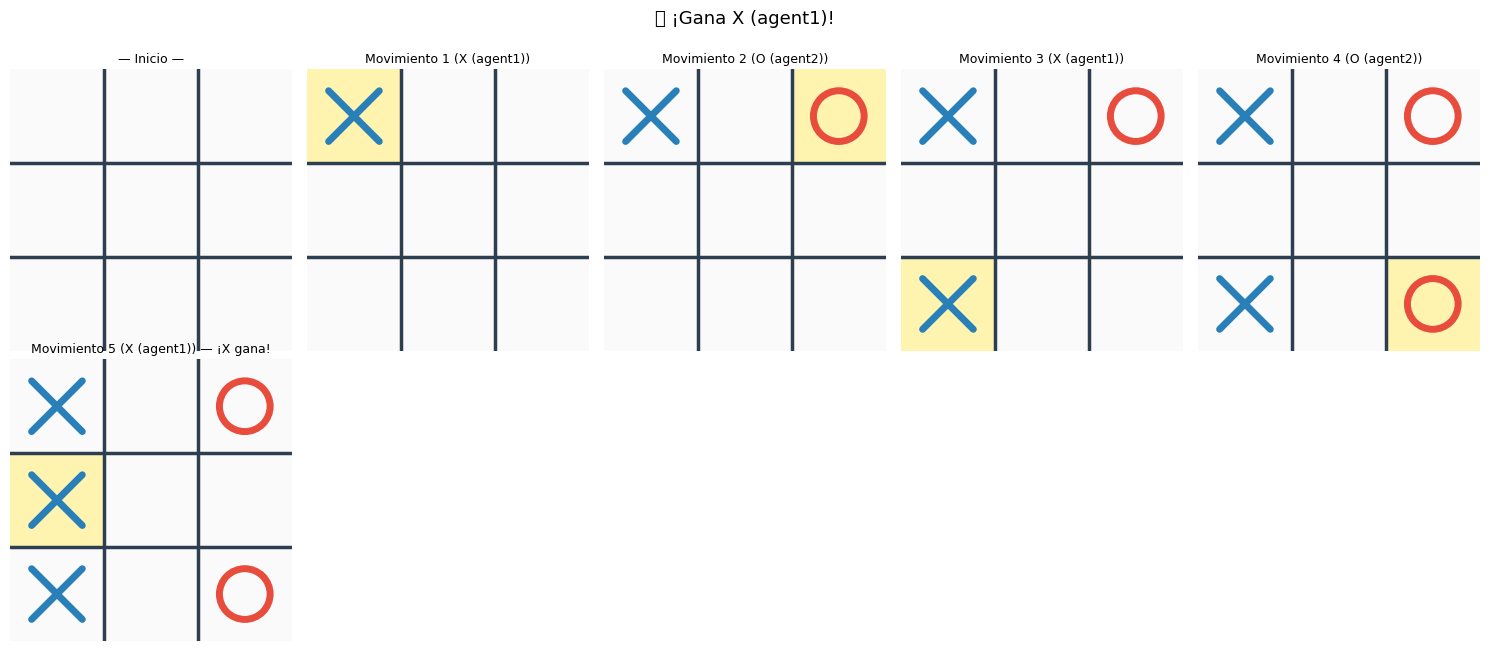

In [41]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


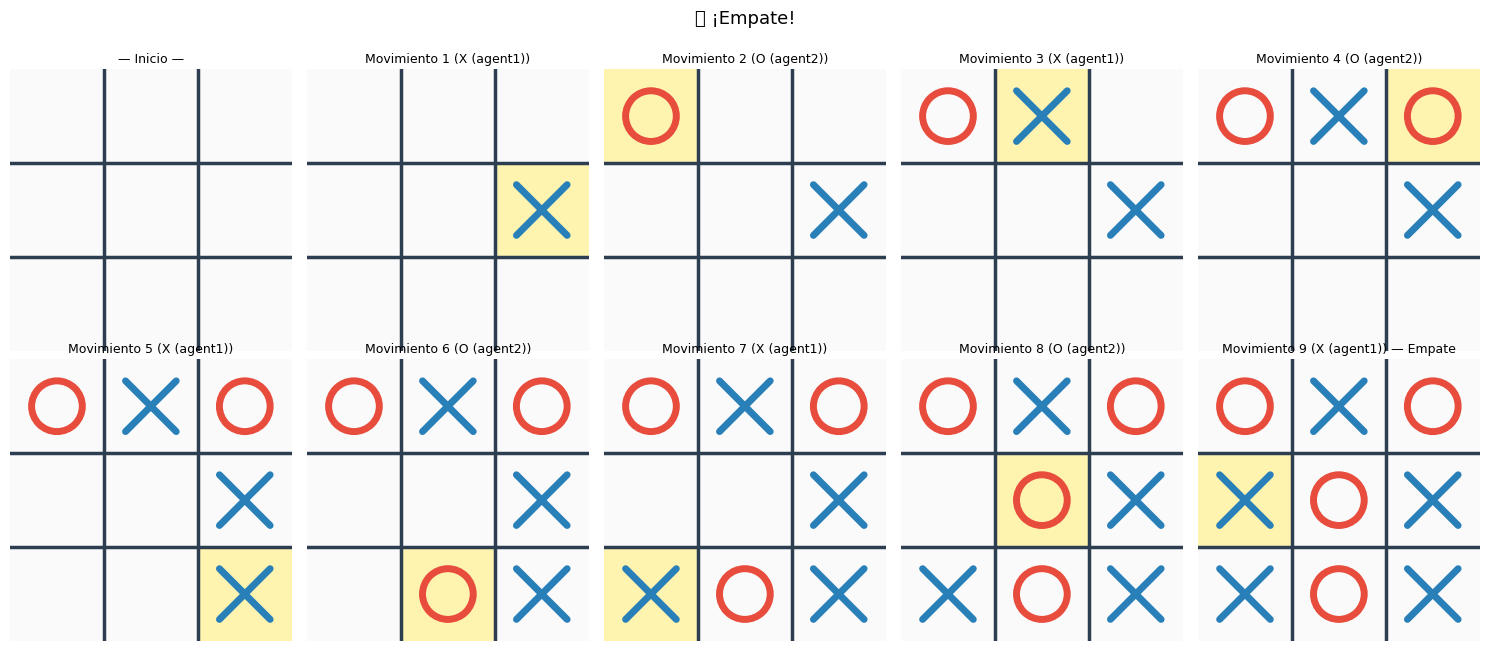

In [42]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


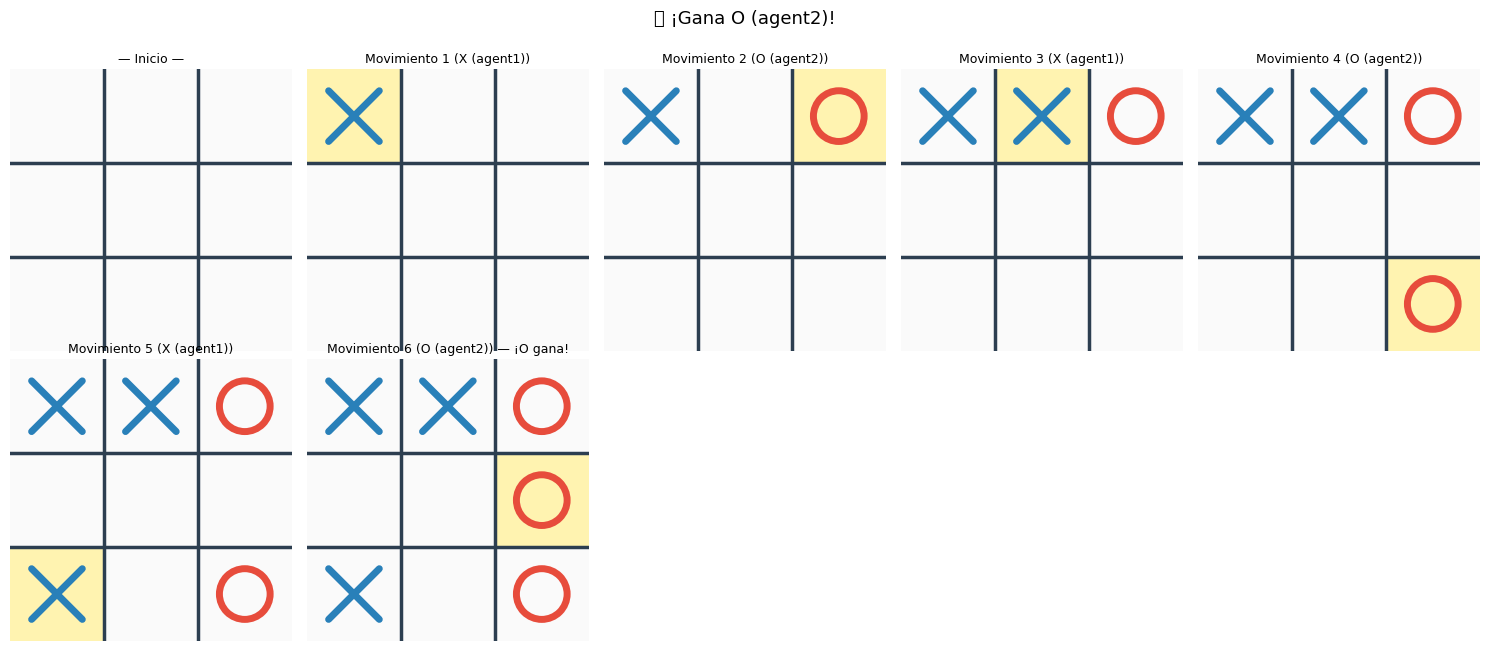

In [43]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

In [44]:
#Buscando buen balance entre explroacion y explotacion
agent1 = Agent(alpha=0.1, prob_exp=0.5)
agent2 = Agent(alpha=0.1, prob_exp=0.5)

game = Game(agent1, agent2)

game.selfplay(300000)

100%|██████████| 300000/300000 [09:55<00:00, 503.99it/s]


[127513, 128090]

In [45]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[-1. 0. 0. 1. 1. 1. 0. 0. -1.],1.0
1,[ 0. 0. 1. 1. 1. -1. 1. -1. -1.],1.0
2,[-1. 1. 1. 1. 1. -1. 1. -1. -1.],1.0
3,[ 0. 0. 0. 1. 1. 1. -1. 0. -1.],1.0
4,[ 0. 0. -1. 1. 1. 1. 0. 0. -1.],1.0
...,...,...
8509,[ 1. 1. -1. 0. -1. 0. -1. -1. 1.],0.0
8510,[-1. -1. -1. 0. 1. 1. -1. 1. 0.],0.0
8511,[ 0. 1. -1. 0. 0. 1. -1. 0. 1.],0.0
8512,[-1. 1. 1. -1. 0. -1. -1. 1. 0.],0.0


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


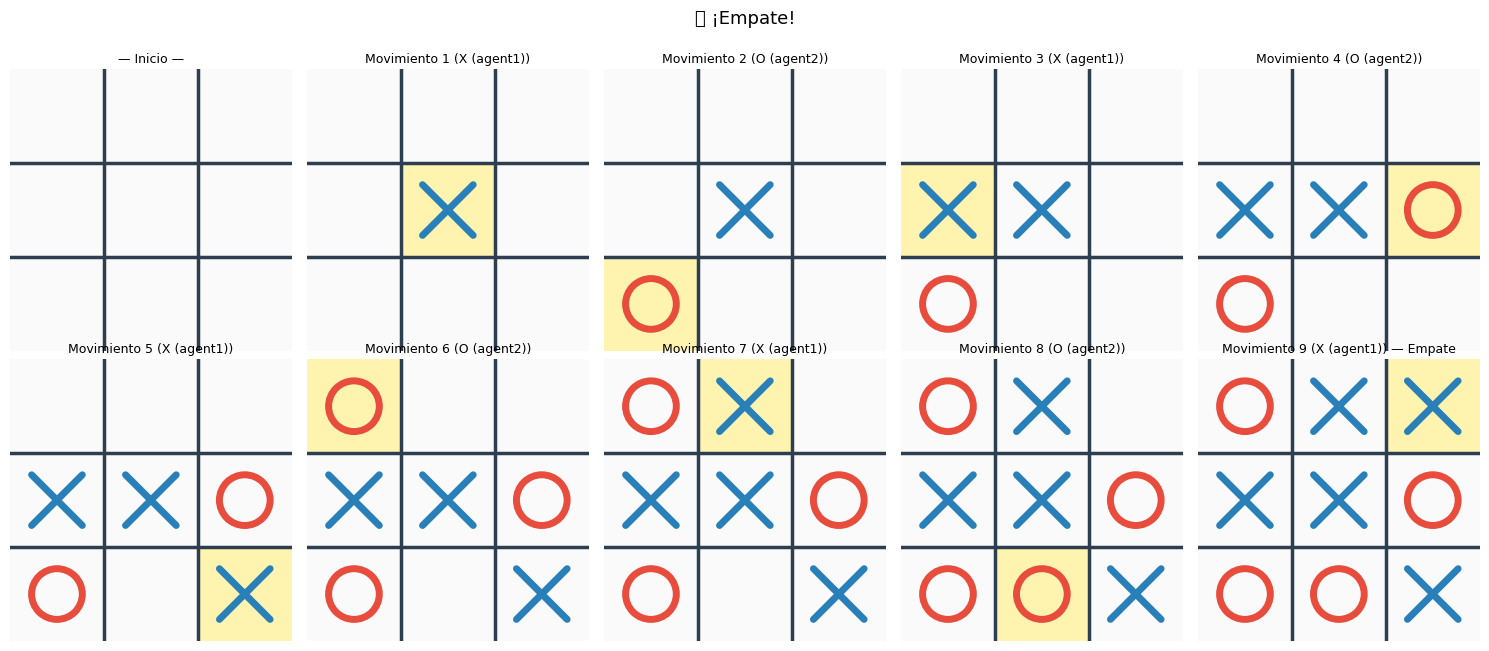

In [47]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


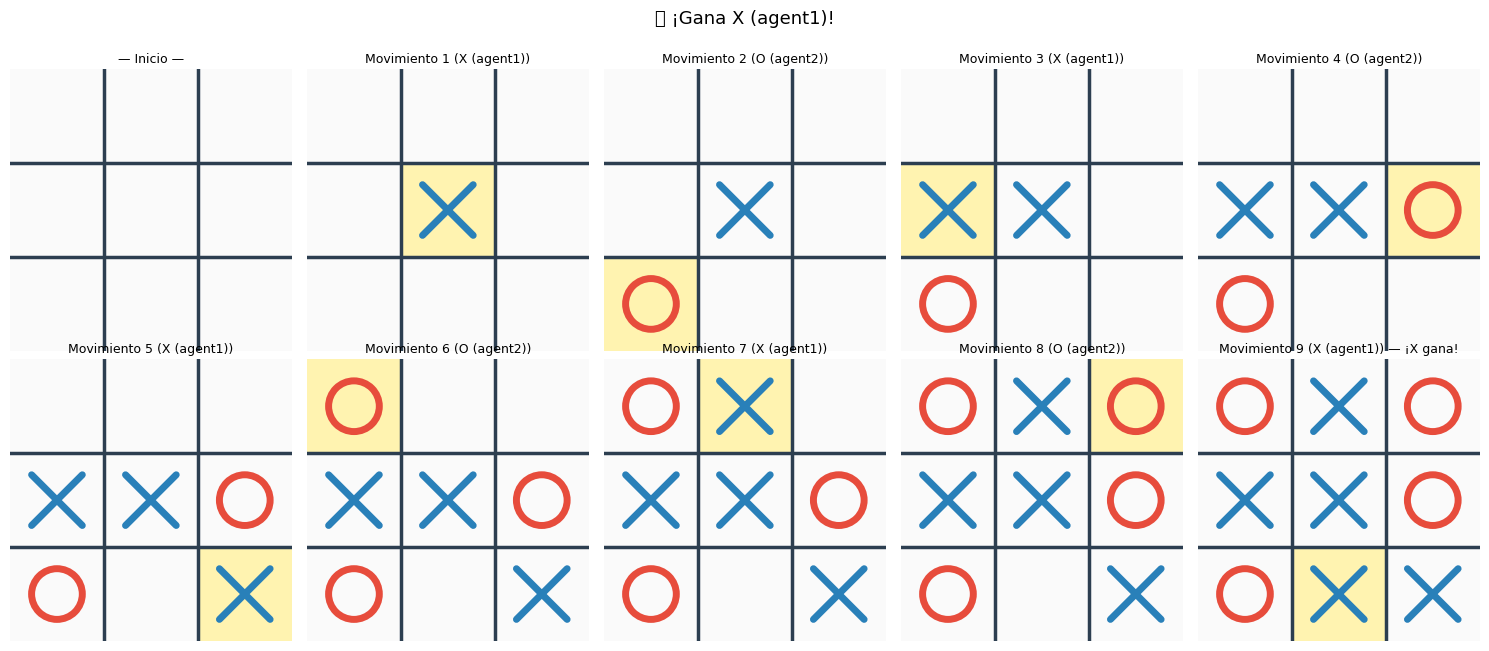

In [46]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


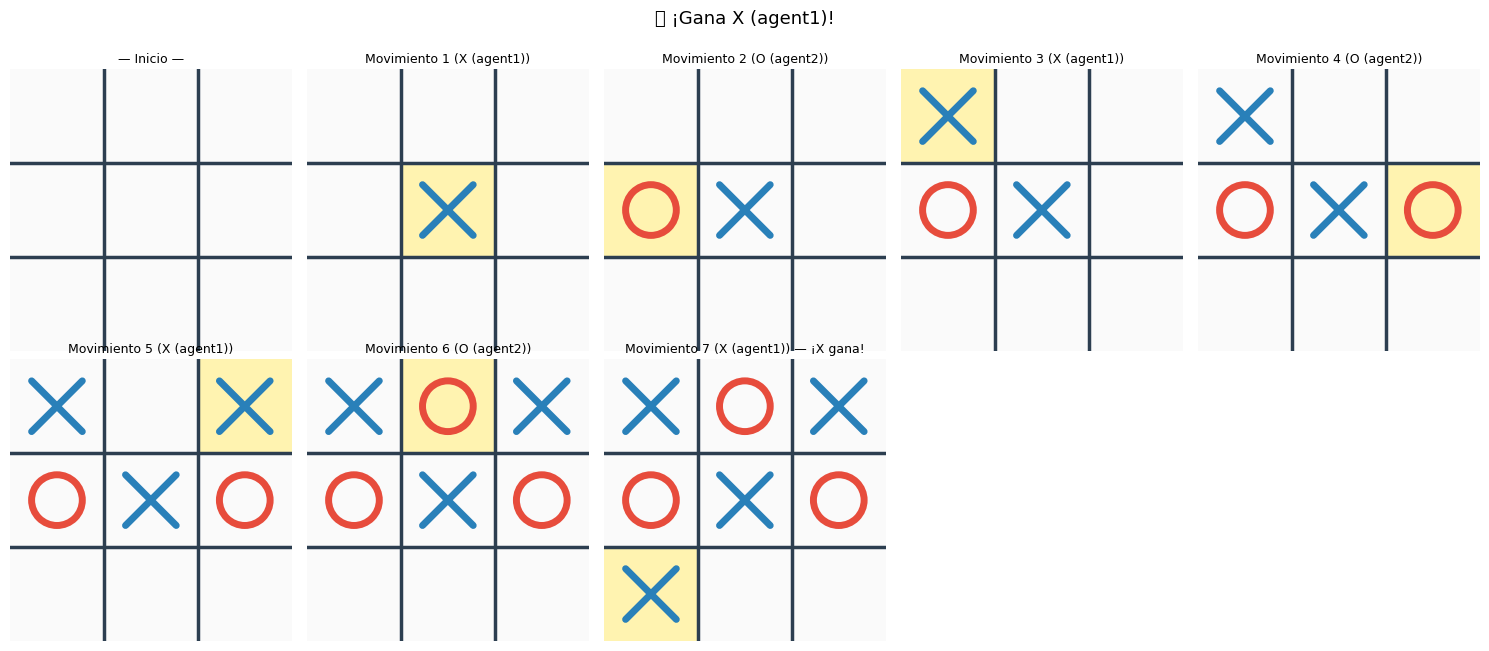

In [51]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


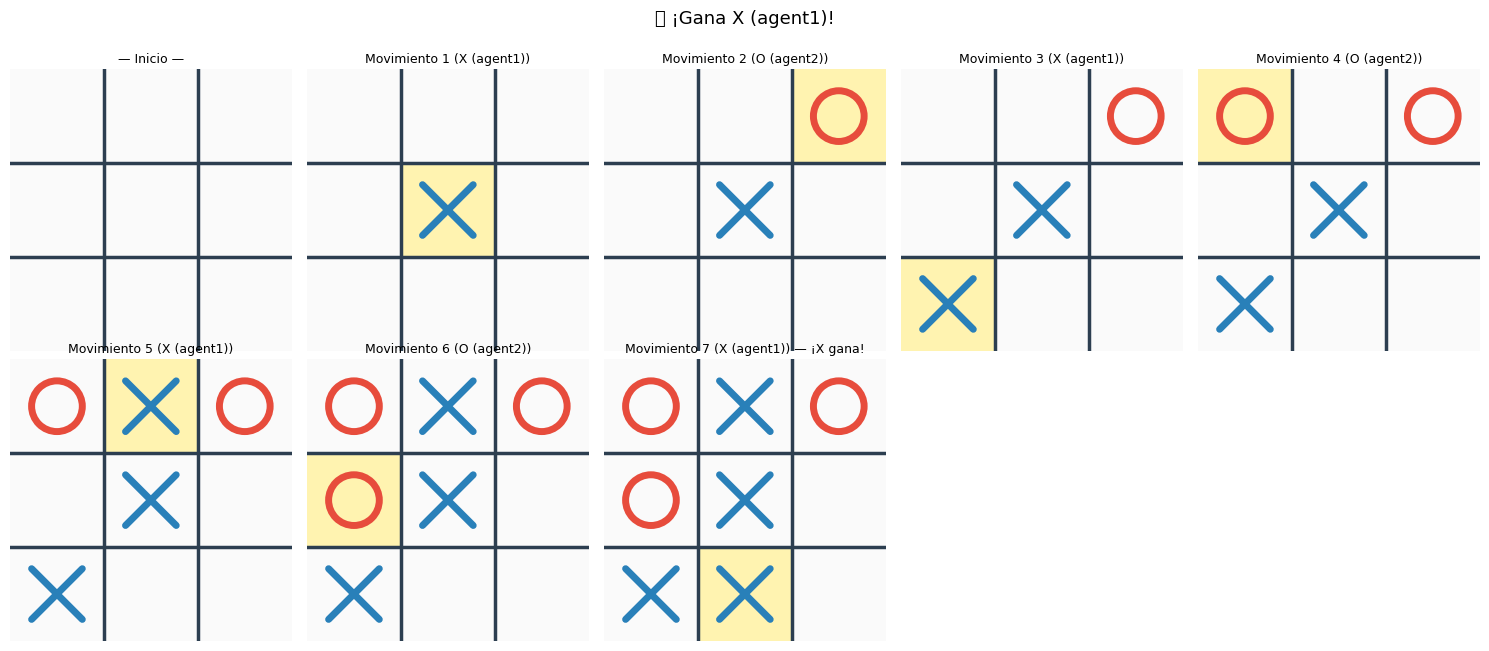

In [50]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

In [75]:
#Buscando buen balance entre explroacion y explotacion
agent1 = Agent(alpha=0.1, prob_exp=0.5)
agent2 = Agent(alpha=0.1, prob_exp=0.2)

game = Game(agent1, agent2)

game.selfplay(300000)

100%|██████████| 300000/300000 [10:54<00:00, 458.69it/s]


[96659, 142126]

In [53]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[ 1. 1. 1. 0. -1. -1. 1. -1. -1.],1.0
1,[ 0. 0. -1. 1. 1. 1. 1. -1. -1.],1.0
2,[ 1. -1. 1. 1. -1. -1. 1. 1. -1.],1.0
3,[ 0. 0. 1. 0. 1. -1. 1. -1. -1.],1.0
4,[ 0. 0. 1. -1. 1. 0. 1. 0. -1.],1.0
...,...,...
6951,[-1. 1. 1. -1. -1. -1. 0. 0. 1.],0.0
6952,[ 0. 1. -1. 1. -1. 0. -1. 1. 0.],0.0
6953,[-1. 1. 1. 1. -1. 0. -1. 0. -1.],0.0
6954,[-1. -1. -1. 0. 0. 1. 0. 1. 1.],0.0


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


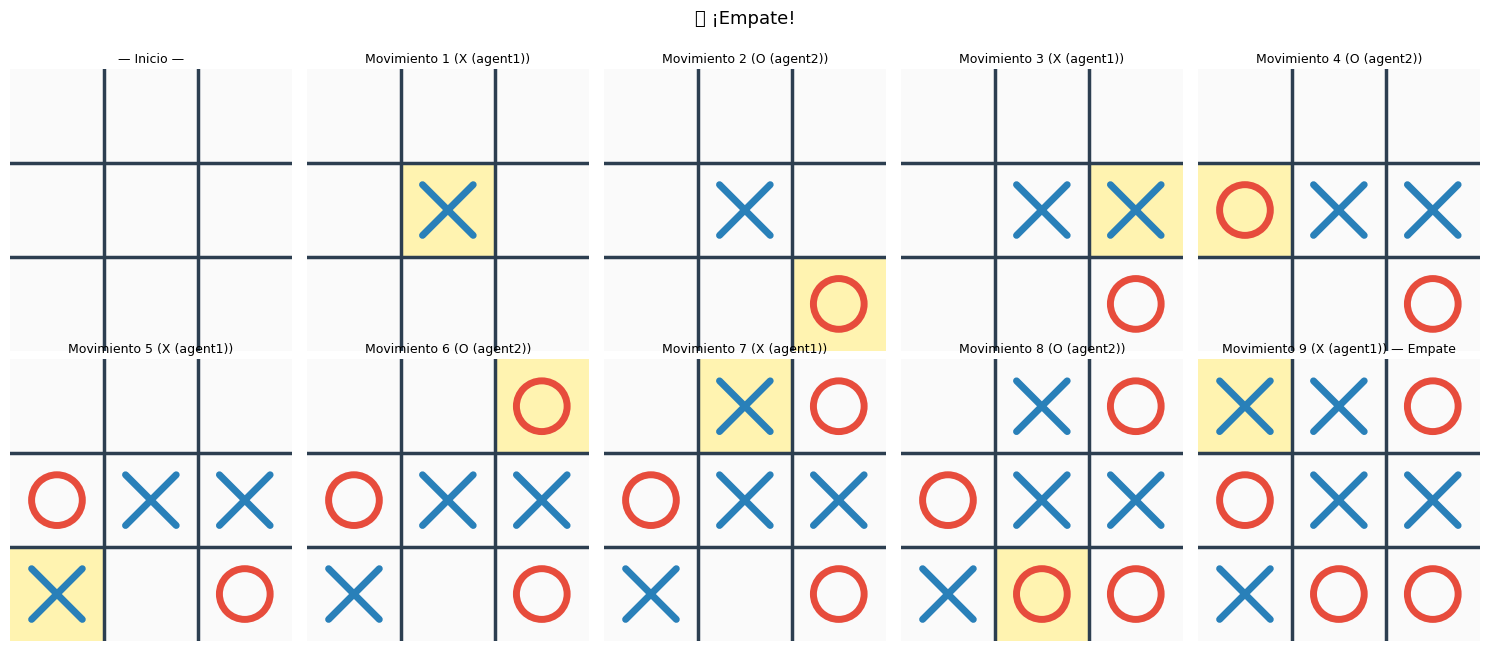

In [55]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


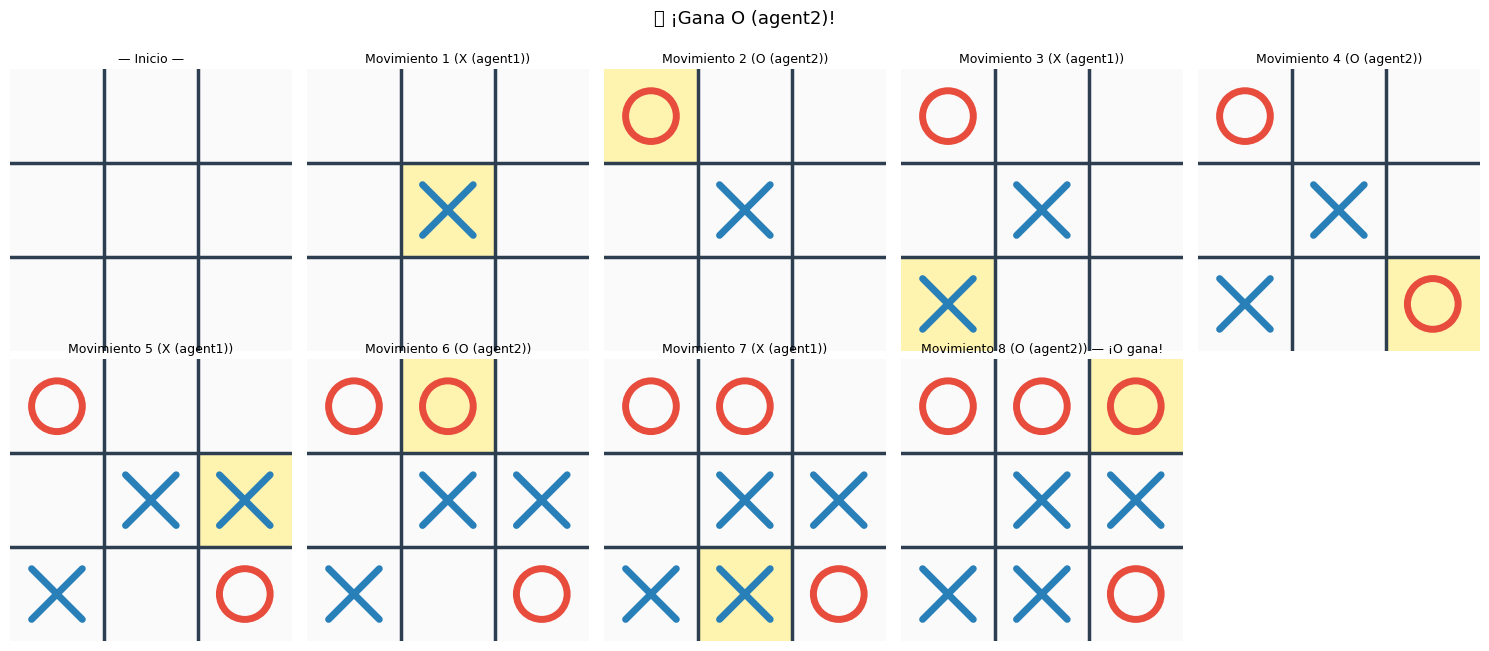

In [56]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


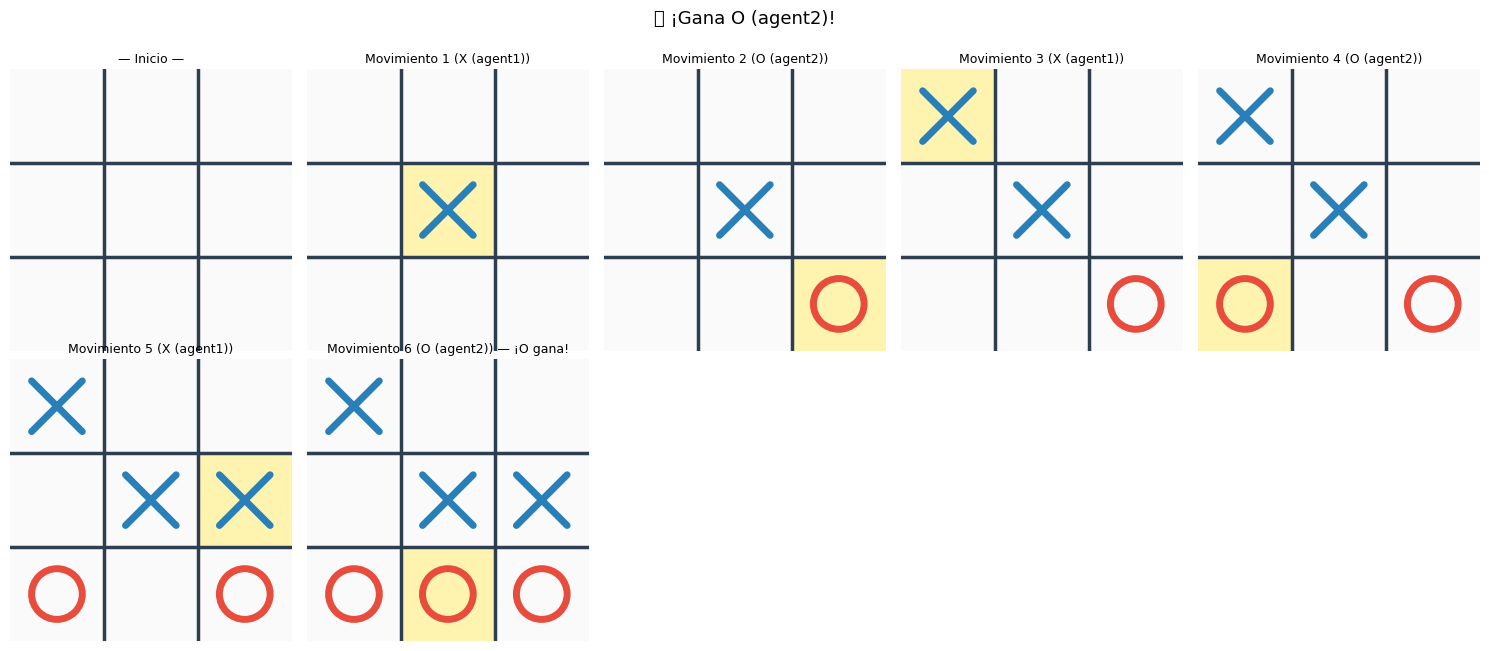

In [58]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


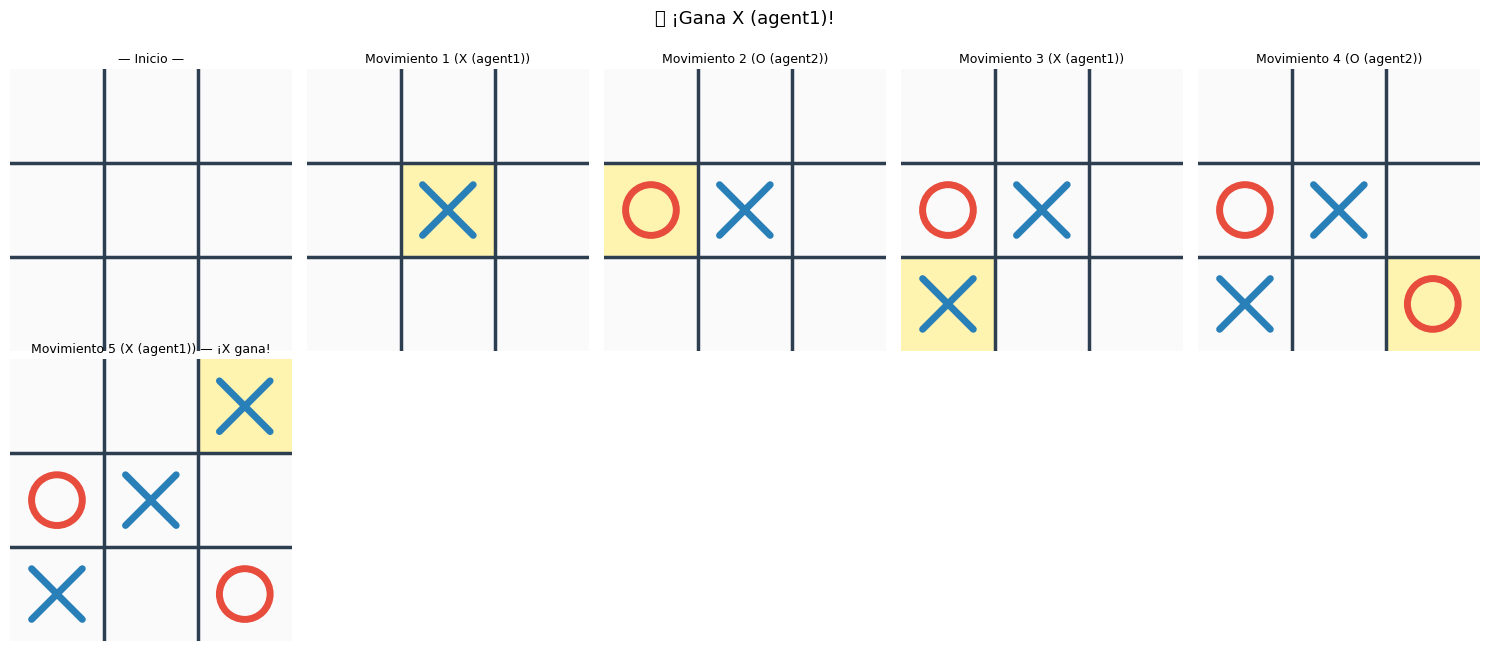

In [61]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

In [ ]:
#Buscando buen balance entre exploracion y explotacion
agent1 = Agent(alpha=0.1, prob_exp=0.5)
agent2 = Agent(alpha=0.1, prob_exp=0.5)

game = Game(agent1, agent2)

game.selfplay(300000)

100%|██████████| 300000/300000 [19:10<00:00, 260.75it/s]


[79390, 90505]

In [64]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[ 1. 1. 1. 1. -1. -1. -1. -1. 1.],1.0
1,[ 0. 0. -1. 0. 0. -1. 1. 1. 1.],1.0
2,[-1. 0. -1. 0. -1. 1. 1. 1. 1.],1.0
3,[-1. 0. 1. 0. 1. -1. 1. -1. 1.],1.0
4,[ 0. 0. 1. -1. 1. -1. 1. -1. 1.],1.0
...,...,...
4243,[ 1. 0. 0. -1. 0. 0. -1. 1. 1.],0.0
4244,[ 1. 0. 0. -1. 0. 0. -1. 1. 0.],0.0
4245,[-1. -1. -1. 1. 1. 0. 1. -1. 1.],0.0
4246,[-1. -1. -1. 0. 0. 1. 1. -1. 1.],0.0


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


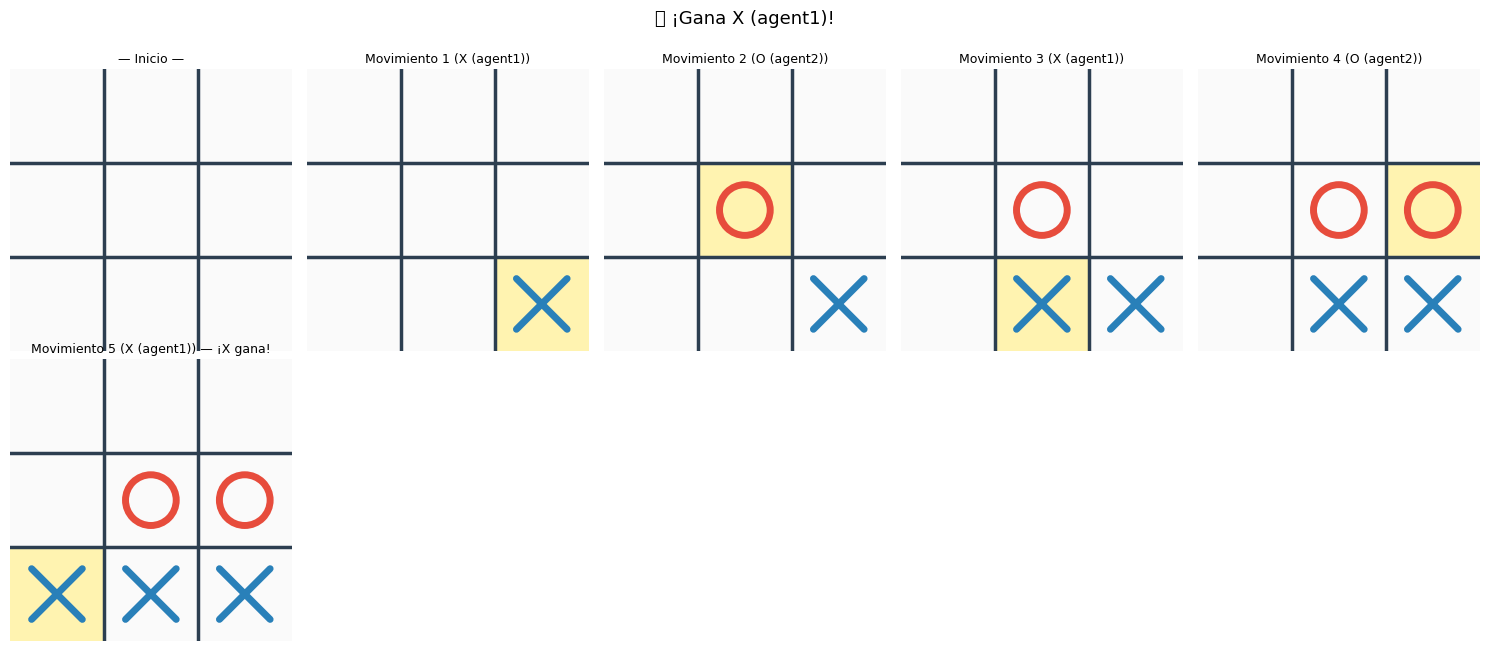

In [68]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


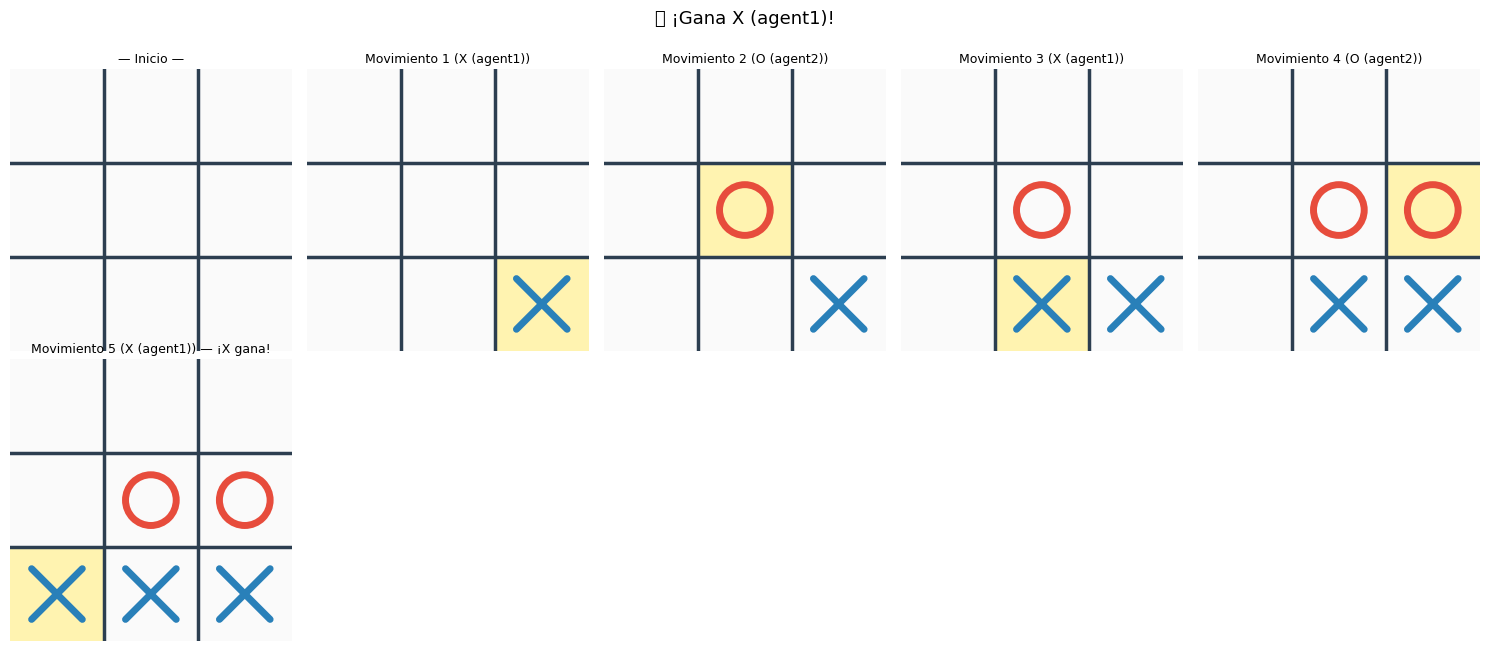

In [69]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

In [70]:
#Buscando buen balance entre exploracion y explotacion
agent1 = Agent(alpha=0.1, prob_exp=0.9)
agent2 = Agent(alpha=0.1, prob_exp=0.9)

game = Game(agent1, agent2)

game.selfplay(300000)

100%|██████████| 300000/300000 [06:05<00:00, 820.65it/s]


[130904, 131441]

In [72]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[ 0. 0. 1. 0. 1. -1. 1. 0. -1.],1.000000
1,[ 1. -1. -1. 0. 1. 1. 0. -1. 1.],1.000000
2,[ 0. 0. 1. 0. 1. -1. 1. -1. -1.],0.999492
3,[ 0. 0. 1. 0. 1. -1. 0. -1. -1.],0.979617
4,[ 0. -1. 1. 0. 1. -1. 1. -1. 1.],0.961848
...,...,...
789,[ 0. 0. 1. 1. 0. 1. -1. 0. -1.],0.000000
790,[ 0. 1. -1. 1. 0. 1. -1. 1. -1.],0.000000
791,[ 0. 1. -1. 1. 0. 1. -1. 0. -1.],0.000000
792,[ 0. 1. 0. 1. 0. 1. -1. 0. -1.],0.000000


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


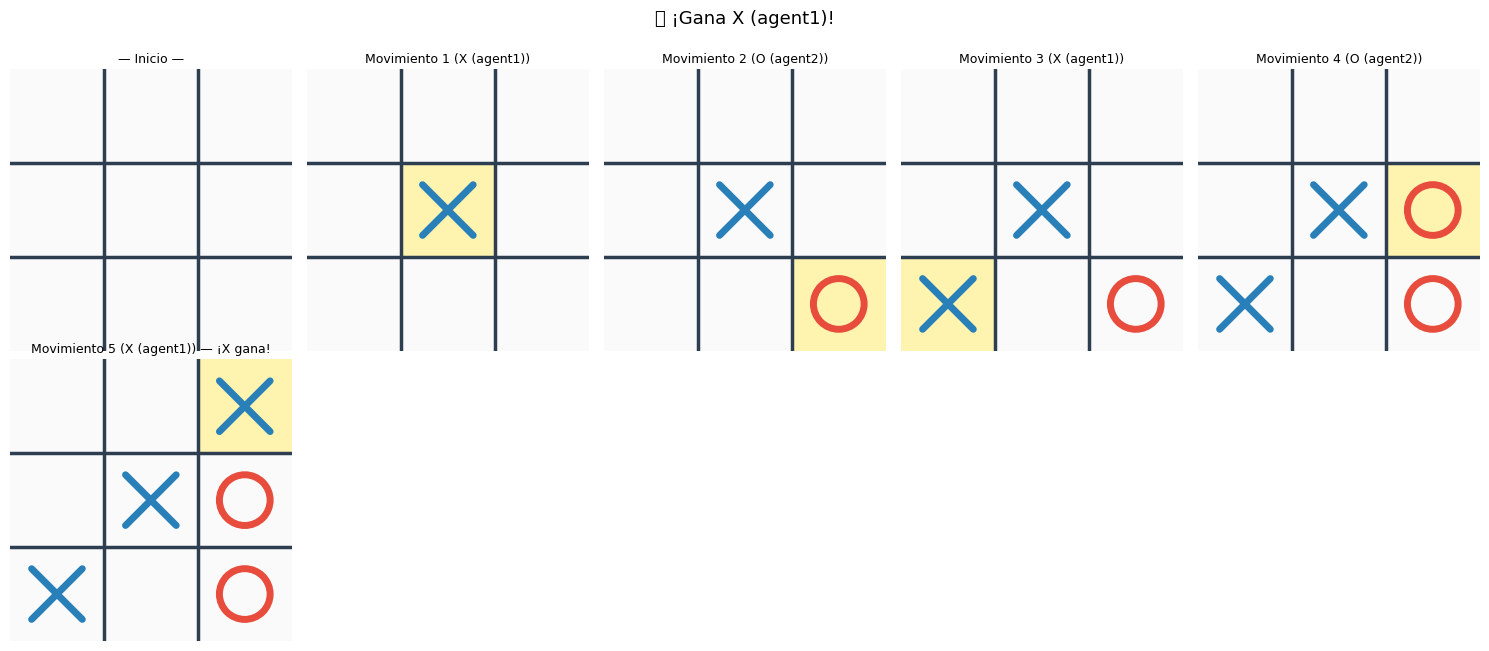

In [73]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


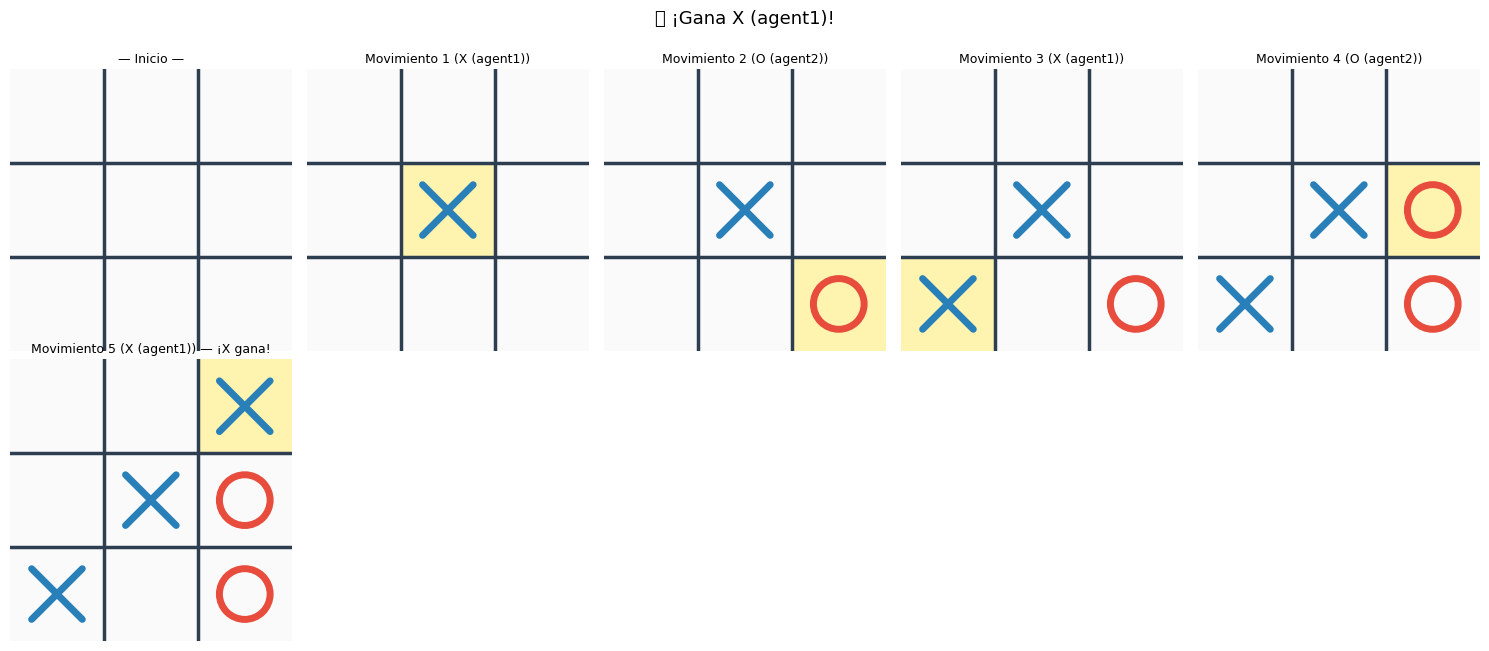

In [74]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

In [ ]:
import numpy as np


class Board():
    def __init__(self):
        self.state = np.zeros((3,3))

    def valid_moves(self):
        return [(i, j) for j in range(3) for i in range(3) if self.state[i, j] == 0]

    def update(self, symbol, row, col):
        if self.state[row, col] == 0:
            self.state[row, col] = symbol
        else:
            raise ValueError ("movimiento ilegal !")

    def is_game_over(self):
        # comprobar filas y columnas
        if (self.state.sum(axis=0) == 3).sum() >= 1 or (self.state.sum(axis=1) == 3).sum() >= 1:
            return 1
        if (self.state.sum(axis=0) == -3).sum() >= 1 or (self.state.sum(axis=1) == -3).sum() >= 1:
            return -1
        # comprobar diagonales
        diag_sums = [
            sum([self.state[i, i] for i in range(3)]),
            sum([self.state[i, 3 - i - 1] for i in range(3)]),
        ]
        if diag_sums[0] == 3 or diag_sums[1] == 3:
            return 1
        if diag_sums[0] == -3 or diag_sums[1] == -3:
            return -1
        # empate
        if len(self.valid_moves()) == 0:
            return 0
        # seguir jugando
        return None

    def reset(self):
        self.state = np.zeros((3,3))

In [ ]:
from tqdm import tqdm


class Game():
    def __init__(self, player1, player2):
        player1.symbol = 1
        player2.symbol = -1
        self.players = [player1, player2]
        self.board = Board()

    def selfplay(self, rounds=100):
        wins = [0, 0]

        for i in tqdm(range(1, rounds + 1)):

            # Partidas impares → player1 primero / pares → player2 primero
            orden = self.players if i % 2 != 0 else list(reversed(self.players))

            self.board.reset()
            for player in self.players:
                player.reset()

            game_over = False
            while not game_over:
                for player in orden:
                    action = player.move(self.board)
                    self.board.update(player.symbol, action[0], action[1])
                    for p in self.players:
                        p.update(self.board)
                    if self.board.is_game_over() is not None:
                        game_over = True
                        break

            self.reward()
            for ix, player in enumerate(self.players):
                if self.board.is_game_over() == player.symbol:
                    wins[ix] += 1

        return wins
    
    def reward(self):
        winner = self.board.is_game_over()
        if winner == 0:
            for player in self.players:
                player.reward(0.5)
        else:
            for player in self.players:
                if winner == player.symbol:
                    player.reward(1)
                else:
                    player.reward(0)

In [ ]:
#Sin alternar turnos
from tqdm import tqdm

class Game():
    def __init__(self, player1, player2):
        player1.symbol = 1
        player2.symbol = -1
        self.players = [player1, player2]
        self.board = Board()

    def selfplay(self, rounds=100):
        wins = [0, 0]
        for i in tqdm(range(1, rounds + 1)):
            self.board.reset()
            for player in self.players:
                player.reset()
            game_over = False
            while not game_over:
                for player in self.players:
                    action = player.move(self.board)
                    self.board.update(player.symbol, action[0], action[1])
                    for player in self.players:
                        player.update(self.board)
                    if self.board.is_game_over() is not None:
                        game_over = True
                        break
            self.reward()
            for ix, player in enumerate(self.players):
                if self.board.is_game_over() == player.symbol:
                    wins[ix] += 1
        return wins


    def reward(self):
        winner = self.board.is_game_over()
        if winner == 0: # empate
            for player in self.players:
                player.reward(0.5)
        else: # le damos 1 recompensa al jugador que gana
            for player in self.players:
                if winner == player.symbol:
                    player.reward(1)
                else:
                    player.reward(0)

In [ ]:
class Agent():
    def __init__(self, alpha=0.5, prob_exp=0.5):
        self.value_function = {} # tabla con pares estado -> valor
        self.alpha = alpha         # learning rate
        self.positions = []       # guardamos todas las posiciones de la partida
        self.prob_exp = prob_exp   # probabilidad de explorar

    def reset(self):
        self.positions = []

    def move(self, board, explore=True):
        valid_moves = board.valid_moves()
        # exploracion
        if explore and np.random.uniform(0, 1) < self.prob_exp:
            # vamos a una posición aleatoria
            ix = np.random.choice(len(valid_moves))
            return valid_moves[ix]
        # explotacion
        # vamos a la posición con más valor
        max_value = -1000
        for row, col in valid_moves:
            next_board = board.state.copy()
            next_board[row, col] = self.symbol
            next_state = str(next_board.reshape(3*3))
            value = 0 if self.value_function.get(next_state) is None else self.value_function.get(next_state)
            if value >= max_value:
                max_value = value
                best_row, best_col = row, col
        return best_row, best_col

    def update(self, board):
        self.positions.append(str(board.state.reshape(3*3)))


    def reward(self, reward):
        # al final de la partida (cuando recibimos la recompensa)
        # iteramos por tods los estados actualizando su valor en la tabla
        for p in reversed(self.positions):
            if self.value_function.get(p) is None:
                self.value_function[p] = 0
            self.value_function[p] += self.alpha * (reward - self.value_function[p])
            reward = self.value_function[p]

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
def dibujar_tablero(ax, estado, titulo='', resaltar=None):
    """
    Dibuja un tablero 3x3 en el eje `ax`.

    Parámetros
    ----------
    ax        : eje de matplotlib donde dibujar.
    estado    : np.ndarray de forma (3,3) con valores 0, 1 o -1.
    titulo    : texto que aparece sobre el tablero.
    resaltar  : tupla (fila, col) de la celda a resaltar, o None.
    """
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect('equal')
    ax.axis('off')

    # Fondo
    ax.add_patch(patches.Rectangle((0, 0), 3, 3, color='#fafafa', zorder=0))

    # Resaltar la celda del último movimiento
    if resaltar is not None:
        row, col = resaltar
        ax.add_patch(patches.Rectangle(
            (col, 2 - row), 1, 1,
            color='#fff3b0', zorder=1, linewidth=0
        ))

    # Líneas de la cuadrícula
    for k in [1, 2]:
        ax.axhline(k, color='#2c3e50', linewidth=2.5, zorder=2)
        ax.axvline(k, color='#2c3e50', linewidth=2.5, zorder=2)

    # Fichas
    for row in range(3):
        for col in range(3):
            v  = estado[row, col]
            cx = col + 0.5
            cy = 2.5 - row   # fila 0 arriba → cy más alto

            if v == 1:   # X – azul
                d = 0.27
                ax.plot([cx - d, cx + d], [cy - d, cy + d],
                        color='#2980b9', linewidth=5, solid_capstyle='round', zorder=3)
                ax.plot([cx - d, cx + d], [cy + d, cy - d],
                        color='#2980b9', linewidth=5, solid_capstyle='round', zorder=3)

            elif v == -1:  # O – rojo
                circ = plt.Circle((cx, cy), 0.27,
                                  fill=False, color='#e74c3c', linewidth=5, zorder=3)
                ax.add_patch(circ)

    if titulo:
        ax.set_title(titulo, fontsize=9, pad=5, fontweight='bold')


In [ ]:
def visualizar_partida(agente1, agente2, explore=False):
    """
    Hace jugar a dos agentes entre sí y muestra todos los estados del tablero,
    desde el tablero vacío hasta el estado final.

    Parámetros
    ----------
    agente1 : Agent (juega con X, símbolo +1).
    agente2 : Agent (juega con O, símbolo -1).
    explore : si True, los agentes pueden explorar; si False, solo explotan.
    """
    board = Board()
    agente1.symbol = 1
    agente2.symbol = -1
    agente1.reset()
    agente2.reset()

    # Registrar el estado inicial y todos los movimientos
    snapshots = [(board.state.copy(), None, '— Inicio —')]
    jugadores  = [agente1, agente2]
    nombres    = ['X (agent1)', 'O (agent2)']
    turno      = 0

    while board.is_game_over() is None:
        jugador  = jugadores[turno % 2]
        nombre   = nombres[turno % 2]
        accion   = jugador.move(board, explore=explore)
        board.update(jugador.symbol, accion[0], accion[1])
        for p in jugadores:
            p.update(board)

        resultado = board.is_game_over()
        if resultado == 1:
            etiqueta = f'Movimiento {turno+1} ({nombre}) — ¡X gana!'
        elif resultado == -1:
            etiqueta = f'Movimiento {turno+1} ({nombre}) — ¡O gana!'
        elif resultado == 0:
            etiqueta = f'Movimiento {turno+1} ({nombre}) — Empate'
        else:
            etiqueta = f'Movimiento {turno+1} ({nombre})'

        snapshots.append((board.state.copy(), accion, etiqueta))
        turno += 1

    # ── Dibujar ──────────────────────────────────────────────────────────
    n  = len(snapshots)
    nc = min(n, 5)          # máximo 5 columnas por fila
    nr = (n + nc - 1) // nc

    fig, axes = plt.subplots(nr, nc, figsize=(3 * nc, 3.2 * nr))
    axes = np.array(axes).reshape(-1) if nr * nc > 1 else [axes]

    for idx, (estado, resaltar, titulo) in enumerate(snapshots):
        dibujar_tablero(axes[idx], estado, titulo=titulo, resaltar=resaltar)

    # Ocultar ejes sobrantes
    for idx in range(len(snapshots), len(axes)):
        axes[idx].axis('off')

    resultado_final = board.is_game_over()
    suptitulo = {1: '🏆 ¡Gana X (agent1)!', -1: '🏆 ¡Gana O (agent2)!', 0: '🤝 ¡Empate!'}
    fig.suptitle(suptitulo.get(resultado_final, ''), fontsize=13, fontweight='bold', y=1.01)

    plt.tight_layout()
    plt.show()
    return resultado_final


In [ ]:
#Probando con alternando turnos y solo 12k iteraciones
agent1 = Agent(alpha=0.1, prob_exp=0.5)
agent2 = Agent(alpha=0.1, prob_exp=0.5)

game = Game(agent1, agent2)

game.selfplay(12000)

100%|██████████| 12000/12000 [00:33<00:00, 357.33it/s]


[5665, 4909]

In [ ]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[ 0. 1. -1. 0. 1. 0. 0. 1. -1.],1.0
1,[ 0. 0. 0. 1. 1. 1. 0. -1. -1.],1.0
2,[ 0. 0. -1. 1. 1. 1. 0. 0. -1.],1.0
3,[ 0. 0. 0. 1. 1. 1. -1. 0. -1.],1.0
4,[ 0. 1. 0. 0. 1. -1. 0. 1. -1.],1.0
...,...,...
6776,[-1. 1. 0. 0. -1. 0. -1. 1. 0.],0.0
6777,[-1. 1. 0. 1. -1. 1. -1. 1. 0.],0.0
6778,[-1. 0. -1. 1. -1. 1. 1. 1. -1.],0.0
6779,[ 1. 1. -1. 0. 0. 0. 1. -1. -1.],0.0


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


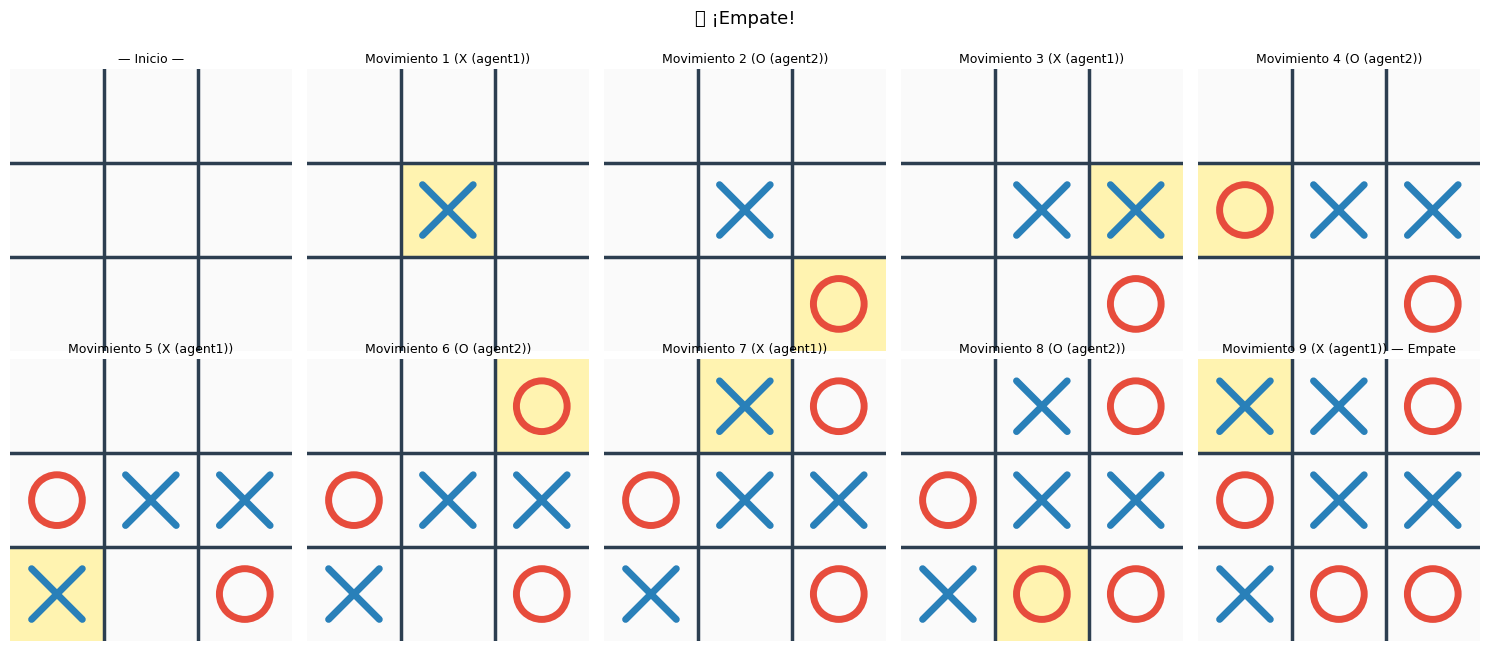

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

In [ ]:
#Probando sin alternar turnos
agent1 = Agent(alpha=0.5, prob_exp=0.5)
agent2 = Agent(alpha=0.5, prob_exp=0.5)

game = Game(agent1, agent2)

game.selfplay(10000)

100%|██████████| 10000/10000 [00:18<00:00, 529.23it/s]


[4195, 4449]

In [ ]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[ 0. 0. 0. 1. 1. 1. -1. 0. -1.],1.0
1,[ 0. 0. 1. 0. 1. -1. 1. 0. -1.],1.0
2,[ 0. 0. 1. 0. -1. 1. 0. -1. 1.],1.0
3,[ 0. 0. -1. 1. 1. 1. 0. 0. -1.],1.0
4,[-1. 0. -1. 1. 1. 1. 0. 0. 0.],1.0
...,...,...
6714,[ 1. 1. -1. -1. 1. 0. -1. -1. 0.],0.0
6715,[ 0. -1. 0. 1. -1. 1. -1. 0. 1.],0.0
6716,[ 0. -1. 0. 1. -1. 0. 1. -1. 1.],0.0
6717,[-1. 1. -1. 1. -1. 0. -1. 1. 1.],0.0


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


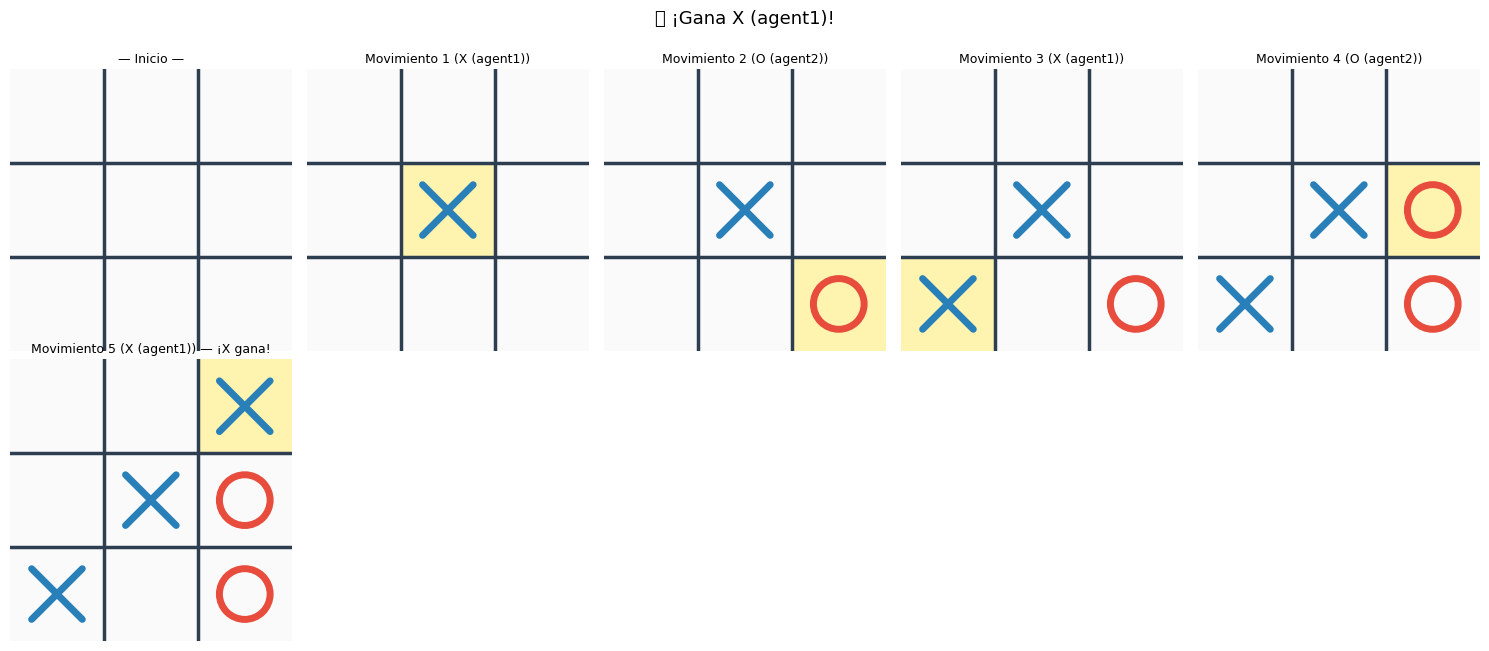

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


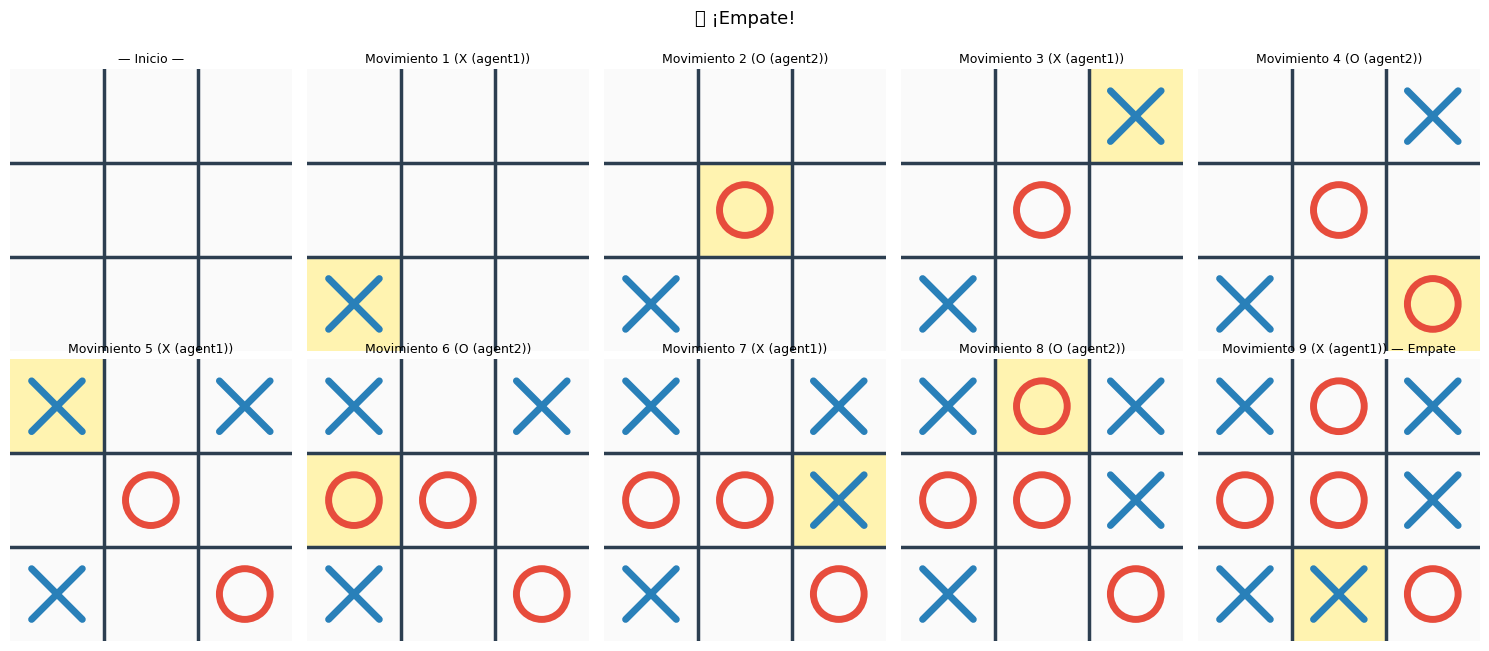

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


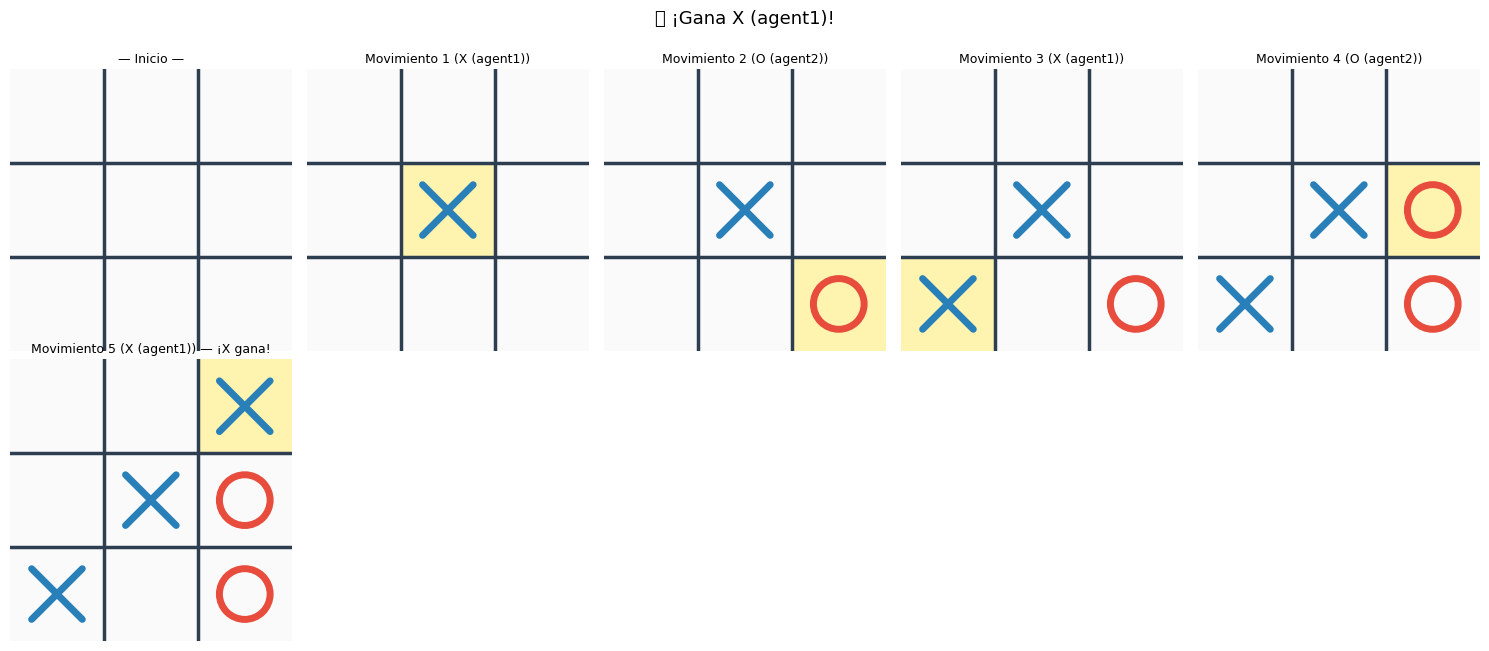

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

In [ ]:
#Probando con alternando turnos y con alpha pequeña para que tome en cuenta muchisimo cada entrenamiento
agent1 = Agent(alpha=0.1, prob_exp=0.5)
agent2 = Agent(alpha=0.1, prob_exp=0.5)

game = Game(agent1, agent2)

game.selfplay(10000)

100%|██████████| 10000/10000 [00:17<00:00, 563.95it/s]


[4638, 4653]

In [ ]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[-1. 0. -1. 0. 0. 0. 1. 1. 1.],1.000000
1,[ 0. -1. -1. 0. 0. 0. 1. 1. 1.],1.000000
2,[ 1. 0. -1. 0. 1. 0. -1. 0. 1.],1.000000
3,[ 1. -1. -1. 0. 1. 0. 0. 0. 1.],0.999998
4,[ 1. 0. -1. 0. 1. 0. 0. -1. 1.],0.999589
...,...,...
5518,[ 1. 0. 0. -1. 1. -1. 0. 1. -1.],0.000000
5519,[ 1. 0. 0. -1. 1. -1. 0. 1. 0.],0.000000
5520,[ 0. 1. -1. -1. -1. 1. -1. 1. 0.],0.000000
5521,[ 0. 1. -1. -1. -1. 1. 0. 1. 0.],0.000000


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


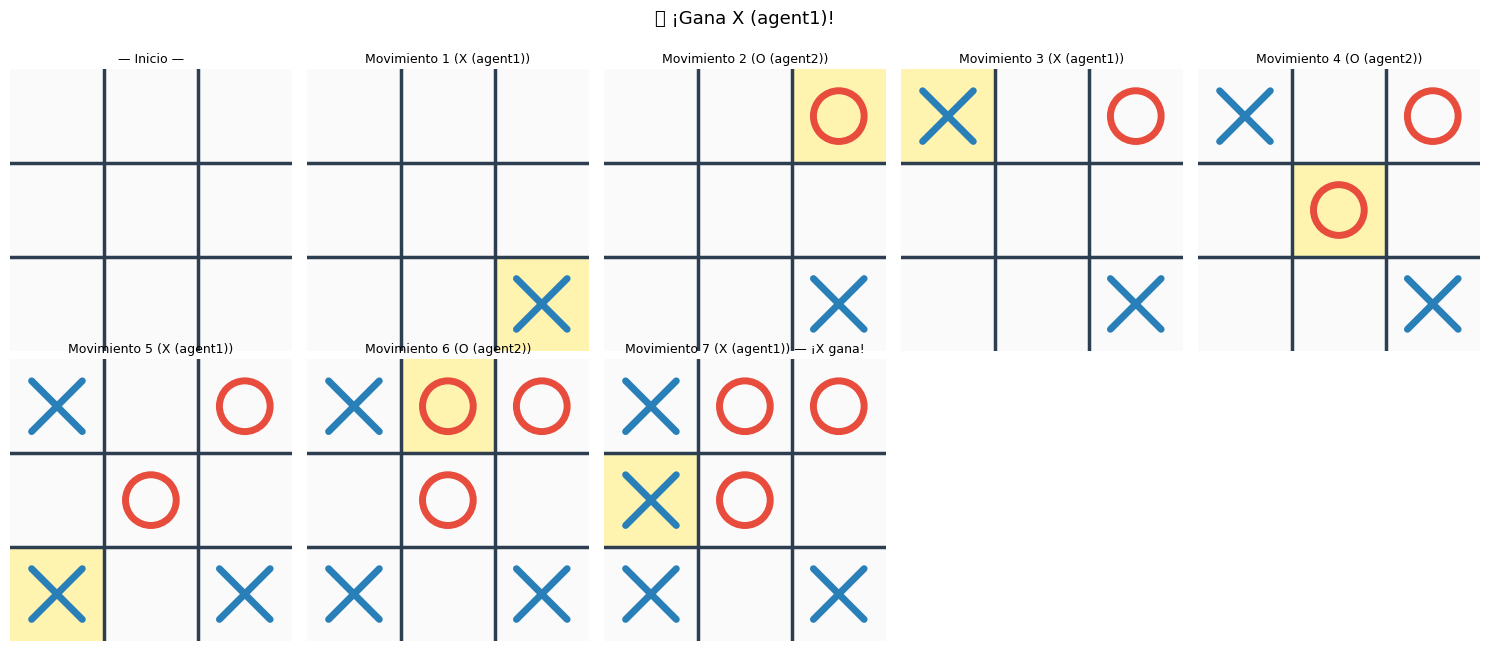

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


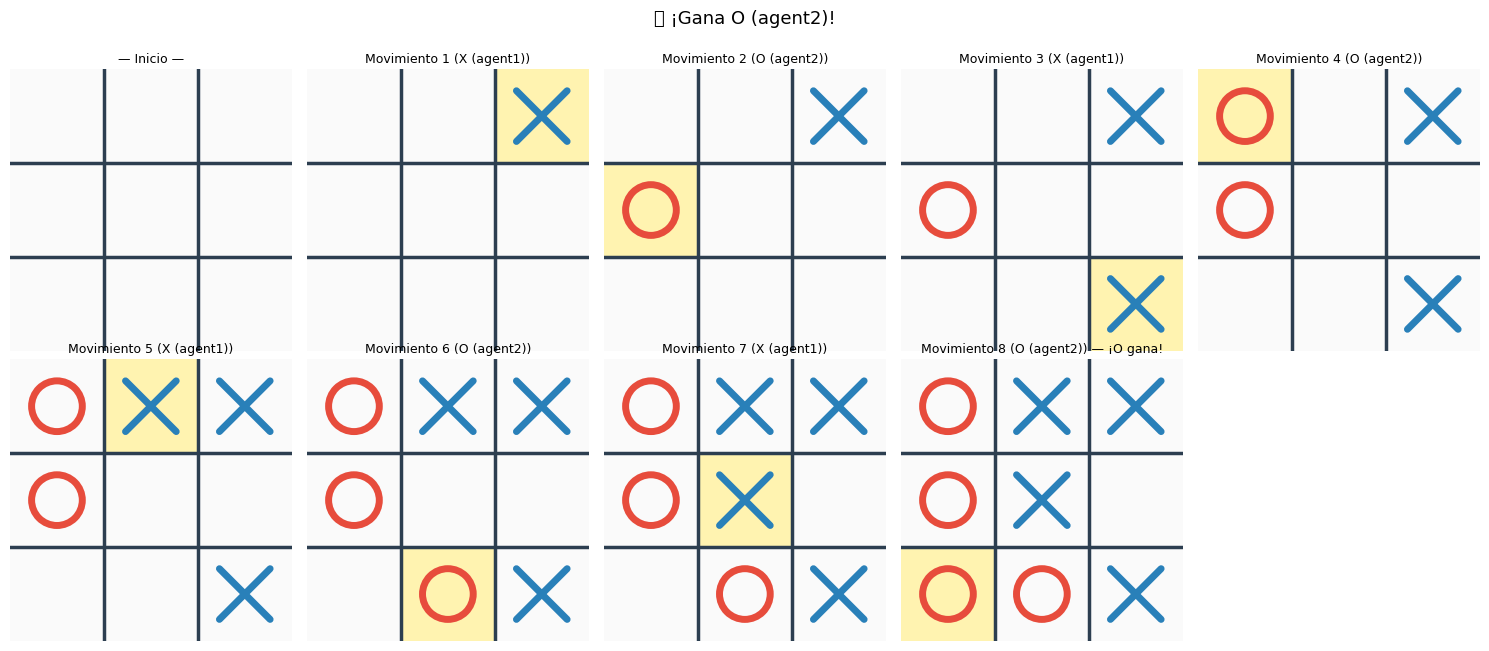

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

In [ ]:
#Probando con alternando turnos y con alpha pequeña para que tome en cuenta muchisimo cada entrenamiento
agent1 = Agent(alpha=0.1, prob_exp=0.2)
agent2 = Agent(alpha=0.1, prob_exp=0.2)

game = Game(agent1, agent2)

game.selfplay(10000)

100%|██████████| 10000/10000 [00:21<00:00, 457.46it/s]


[4475, 4375]

In [ ]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[ 1. 0. 0. 1. 0. -1. 1. 0. -1.],1.000000
1,[ 1. 0. -1. 1. 0. 0. 1. 0. -1.],1.000000
2,[ 1. 0. -1. 1. 0. -1. 1. 0. 0.],1.000000
3,[ 1. 0. -1. 0. 1. 0. -1. 0. 1.],0.999976
4,[ 1. 0. -1. 1. -1. 0. 1. 0. -1.],0.999884
...,...,...
2869,[-1. 0. -1. 1. 0. 0. 0. 0. 0.],0.000000
2870,[ 0. 0. -1. 1. -1. 0. 0. 0. 1.],0.000000
2871,[ 1. 0. -1. 1. 0. -1. -1. 1. -1.],0.000000
2872,[ 1. 1. -1. -1. -1. 1. -1. 0. 1.],0.000000


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


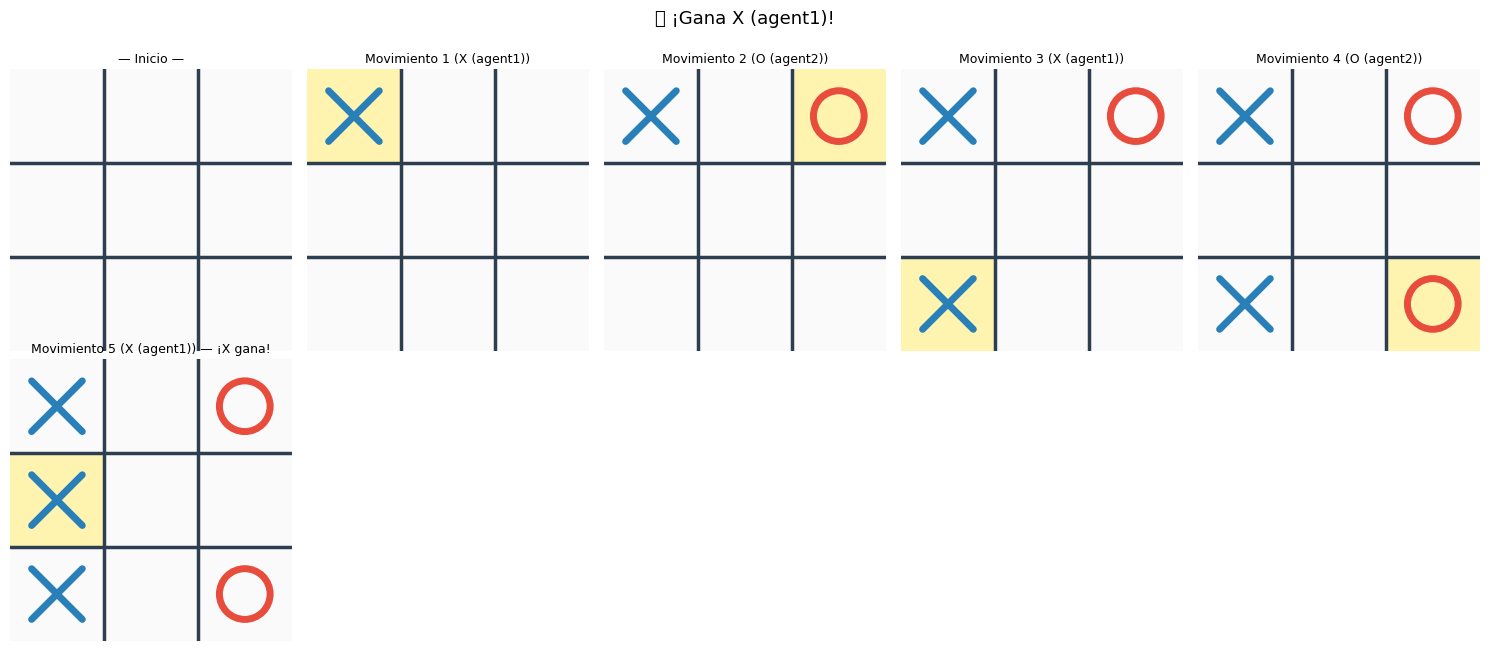

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


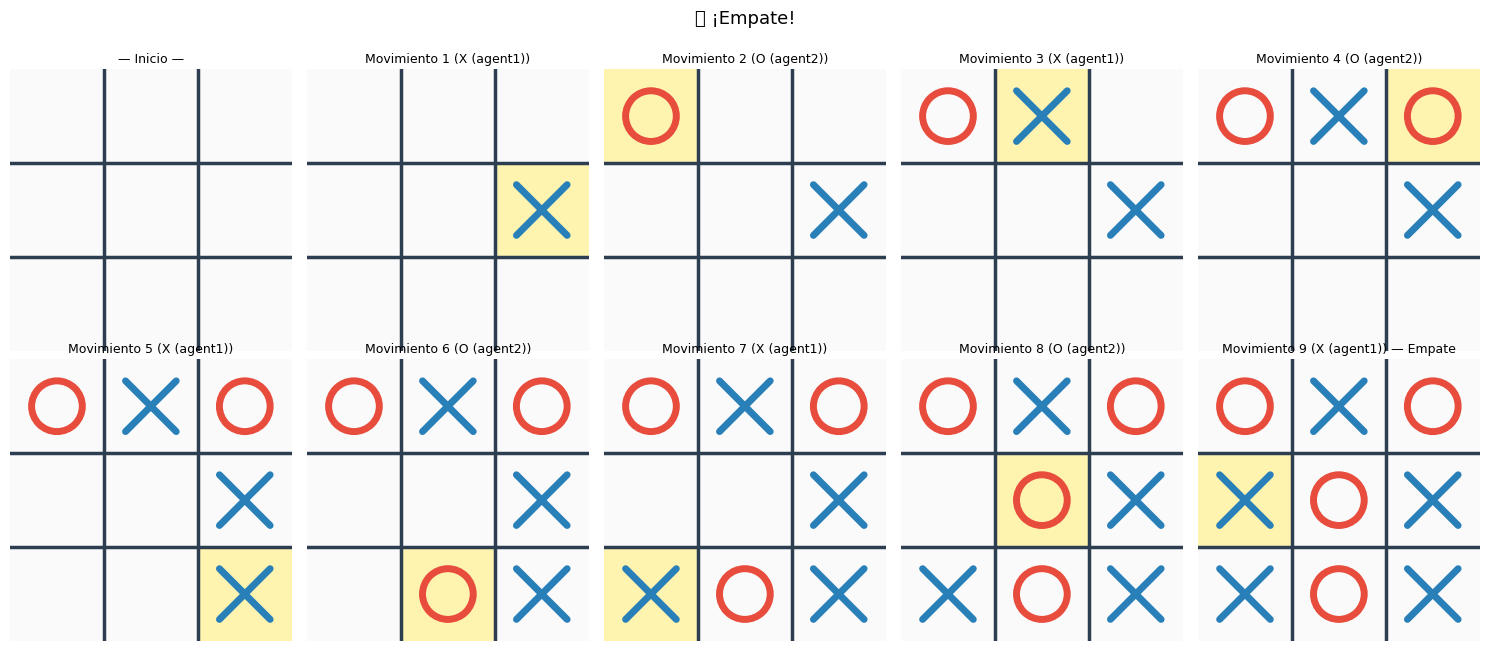

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


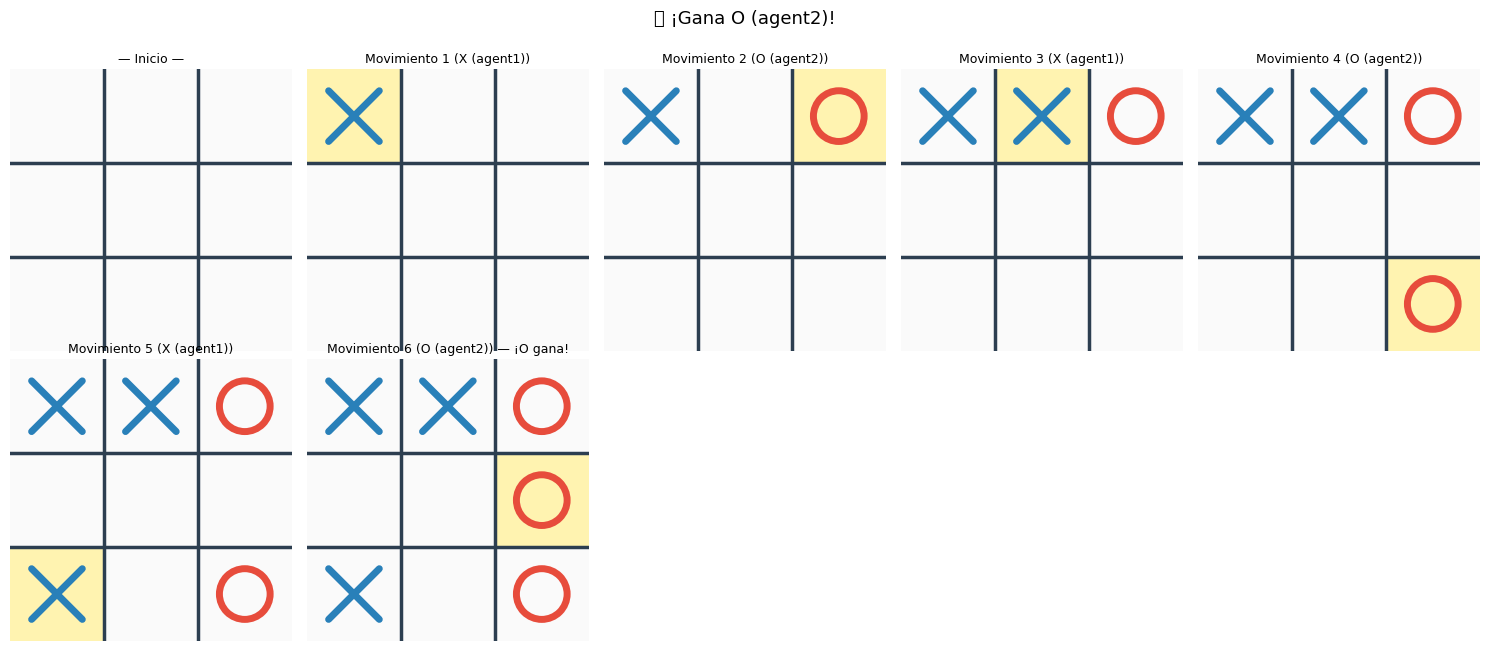

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

In [ ]:
#Buscando buen balance entre explroacion y explotacion
agent1 = Agent(alpha=0.1, prob_exp=0.5)
agent2 = Agent(alpha=0.1, prob_exp=0.5)

game = Game(agent1, agent2)

game.selfplay(300000)

100%|██████████| 300000/300000 [09:55<00:00, 503.99it/s]


[127513, 128090]

In [ ]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[-1. 0. 0. 1. 1. 1. 0. 0. -1.],1.0
1,[ 0. 0. 1. 1. 1. -1. 1. -1. -1.],1.0
2,[-1. 1. 1. 1. 1. -1. 1. -1. -1.],1.0
3,[ 0. 0. 0. 1. 1. 1. -1. 0. -1.],1.0
4,[ 0. 0. -1. 1. 1. 1. 0. 0. -1.],1.0
...,...,...
8509,[ 1. 1. -1. 0. -1. 0. -1. -1. 1.],0.0
8510,[-1. -1. -1. 0. 1. 1. -1. 1. 0.],0.0
8511,[ 0. 1. -1. 0. 0. 1. -1. 0. 1.],0.0
8512,[-1. 1. 1. -1. 0. -1. -1. 1. 0.],0.0


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


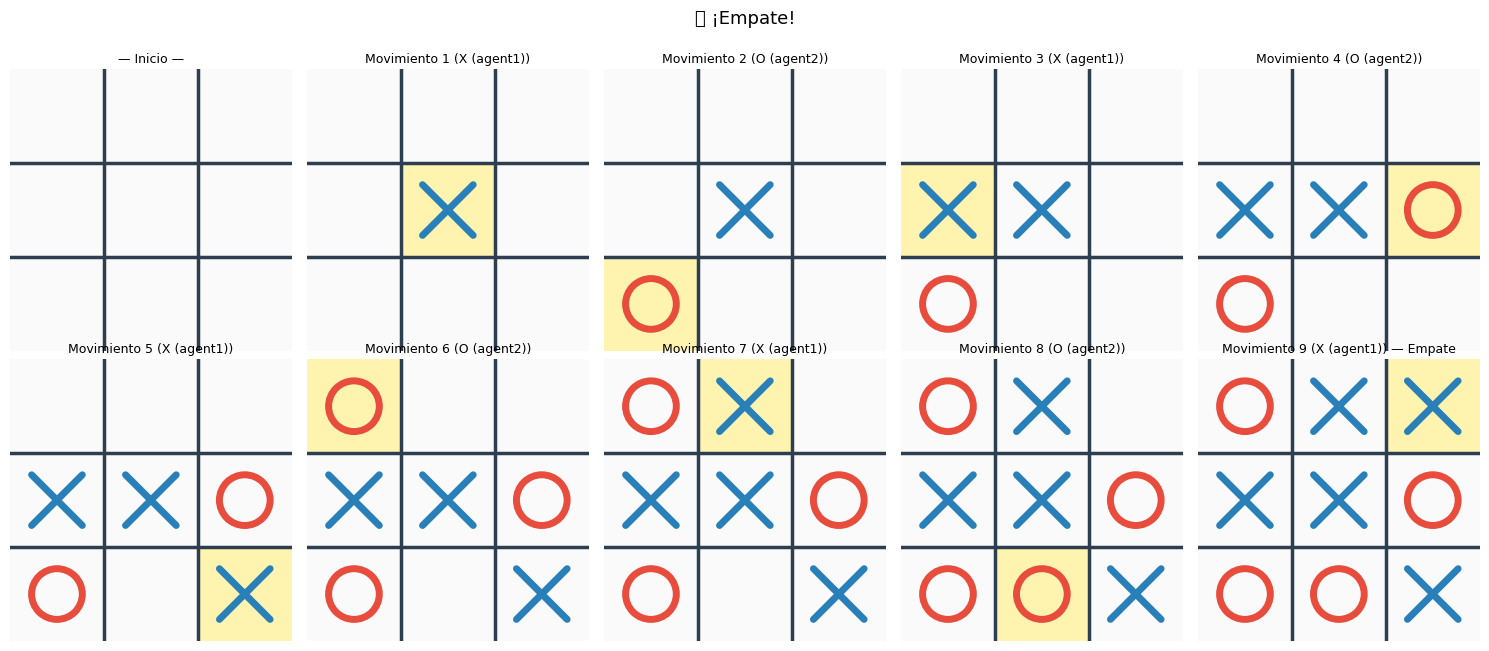

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


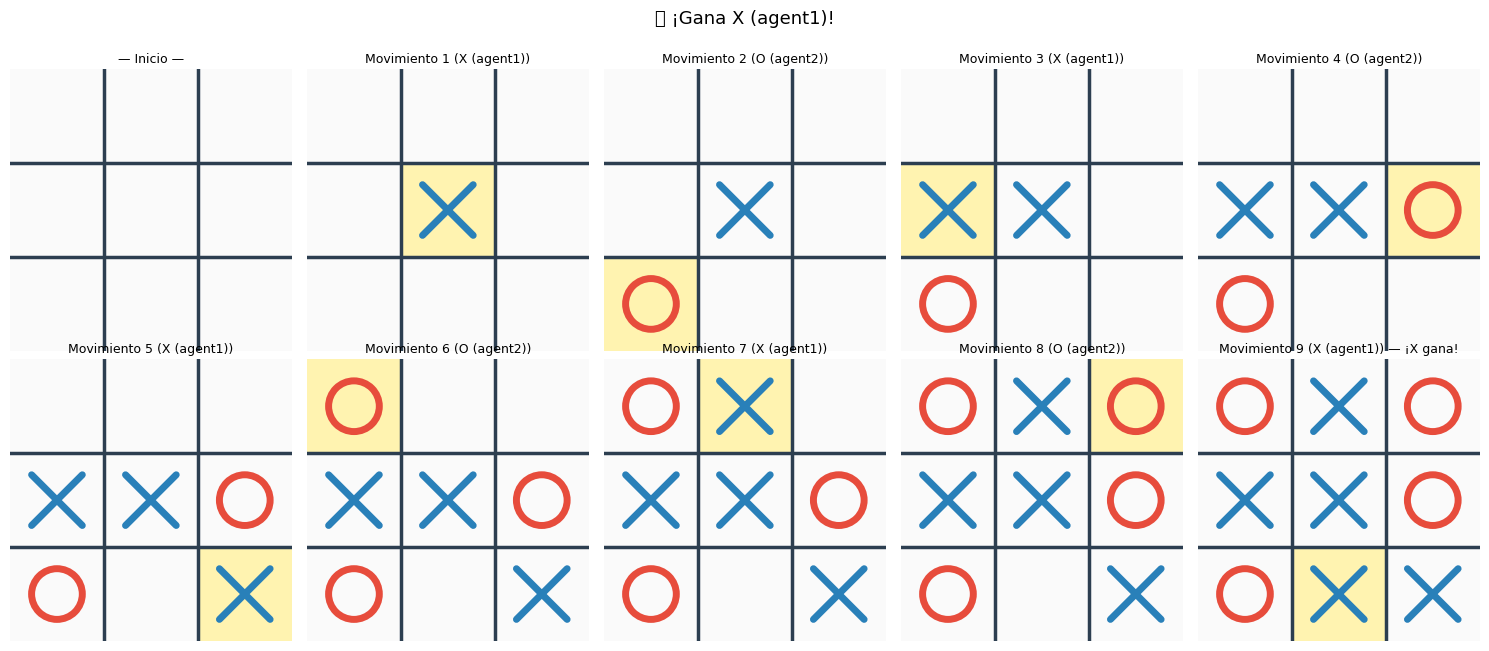

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


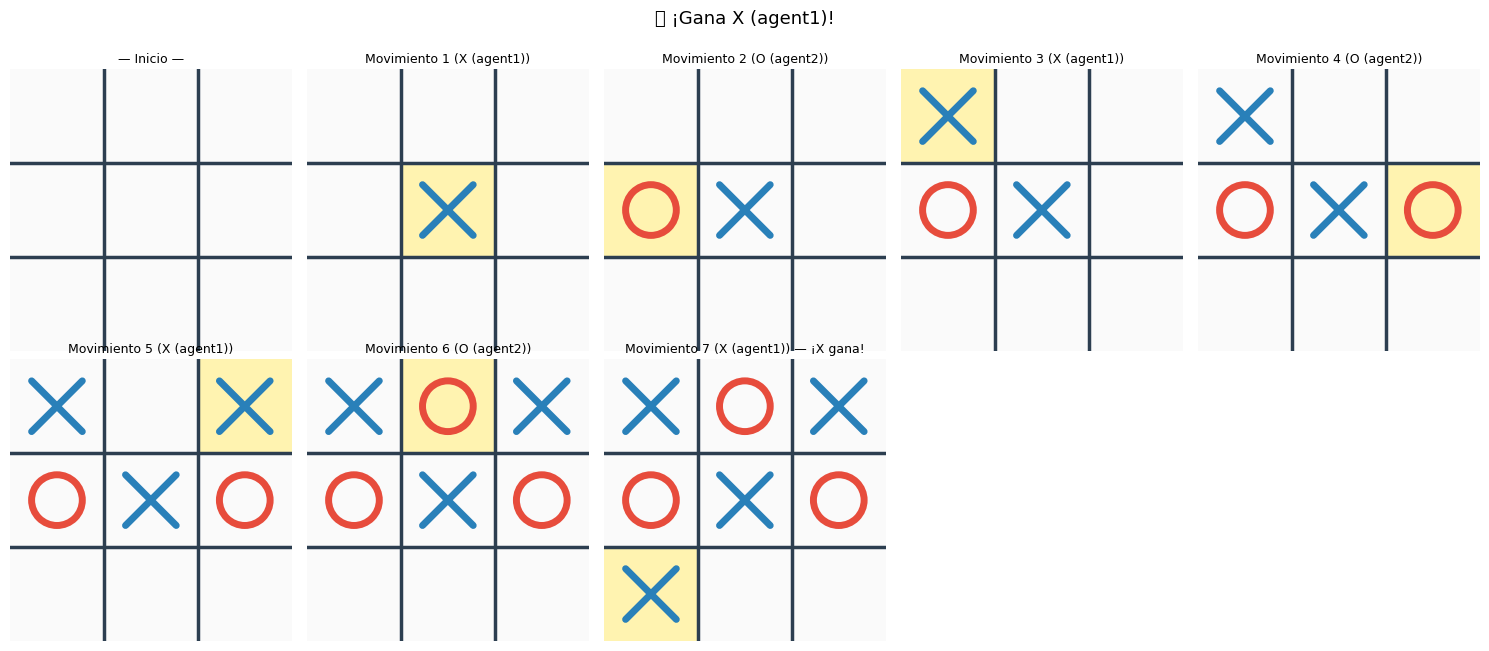

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


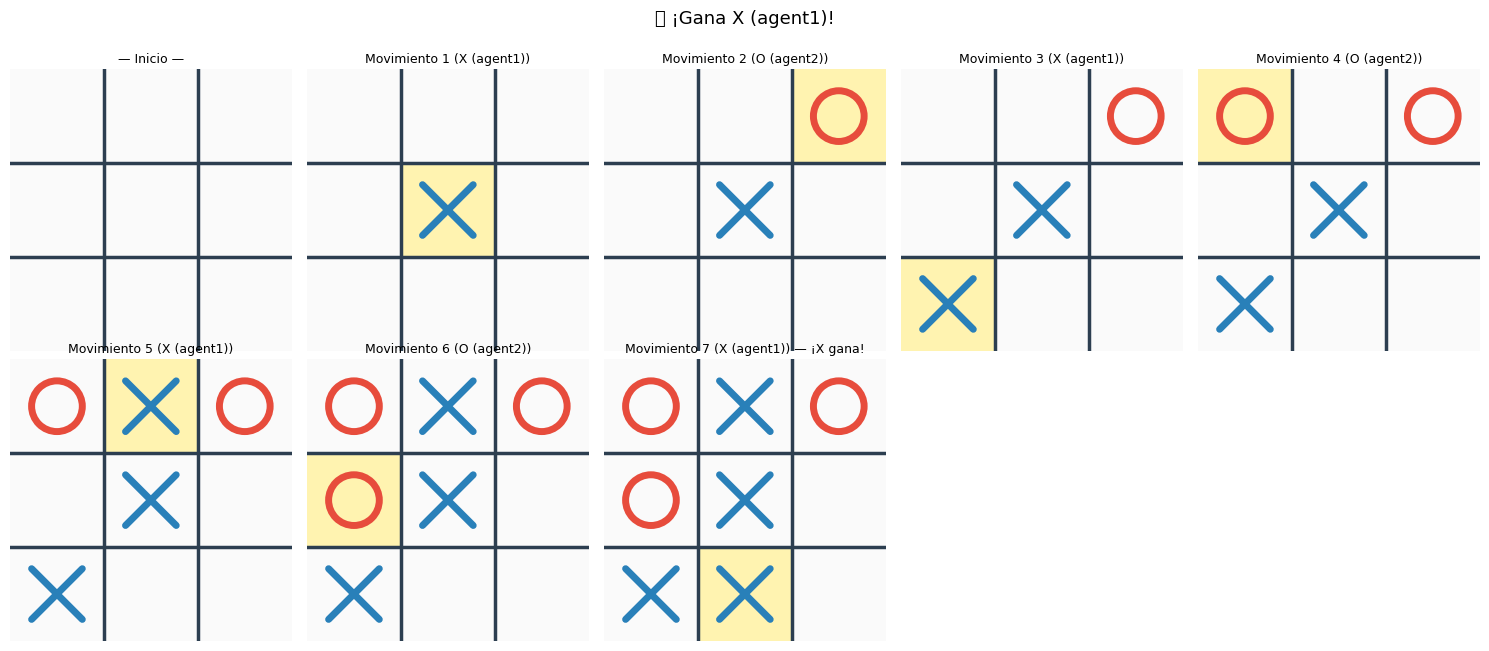

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

In [ ]:
#Buscando buen balance entre explroacion y explotacion
agent1 = Agent(alpha=0.1, prob_exp=0.5)
agent2 = Agent(alpha=0.1, prob_exp=0.2)

game = Game(agent1, agent2)

game.selfplay(300000)

100%|██████████| 300000/300000 [21:40<00:00, 230.68it/s]


[96135, 144377]

In [ ]:
import pandas as pd

funcion_de_valor = sorted(agent1.value_function.items(), key=lambda kv: kv[1], reverse=True)
tabla = pd.DataFrame({'estado': [x[0] for x in funcion_de_valor], 'valor': [x[1] for x in funcion_de_valor]})

tabla

,estado,valor
0,[ 1. 1. 1. 0. -1. -1. 1. -1. -1.],1.0
1,[ 0. 0. -1. 1. 1. 1. 1. -1. -1.],1.0
2,[ 1. -1. 1. 1. -1. -1. 1. 1. -1.],1.0
3,[ 0. 0. 1. 0. 1. -1. 1. -1. -1.],1.0
4,[ 0. 0. 1. -1. 1. 0. 1. 0. -1.],1.0
...,...,...
6951,[-1. 1. 1. -1. -1. -1. 0. 0. 1.],0.0
6952,[ 0. 1. -1. 1. -1. 0. -1. 1. 0.],0.0
6953,[-1. 1. 1. 1. -1. 0. -1. 0. -1.],0.0
6954,[-1. -1. -1. 0. 0. 1. 0. 1. 1.],0.0


Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\aaran\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


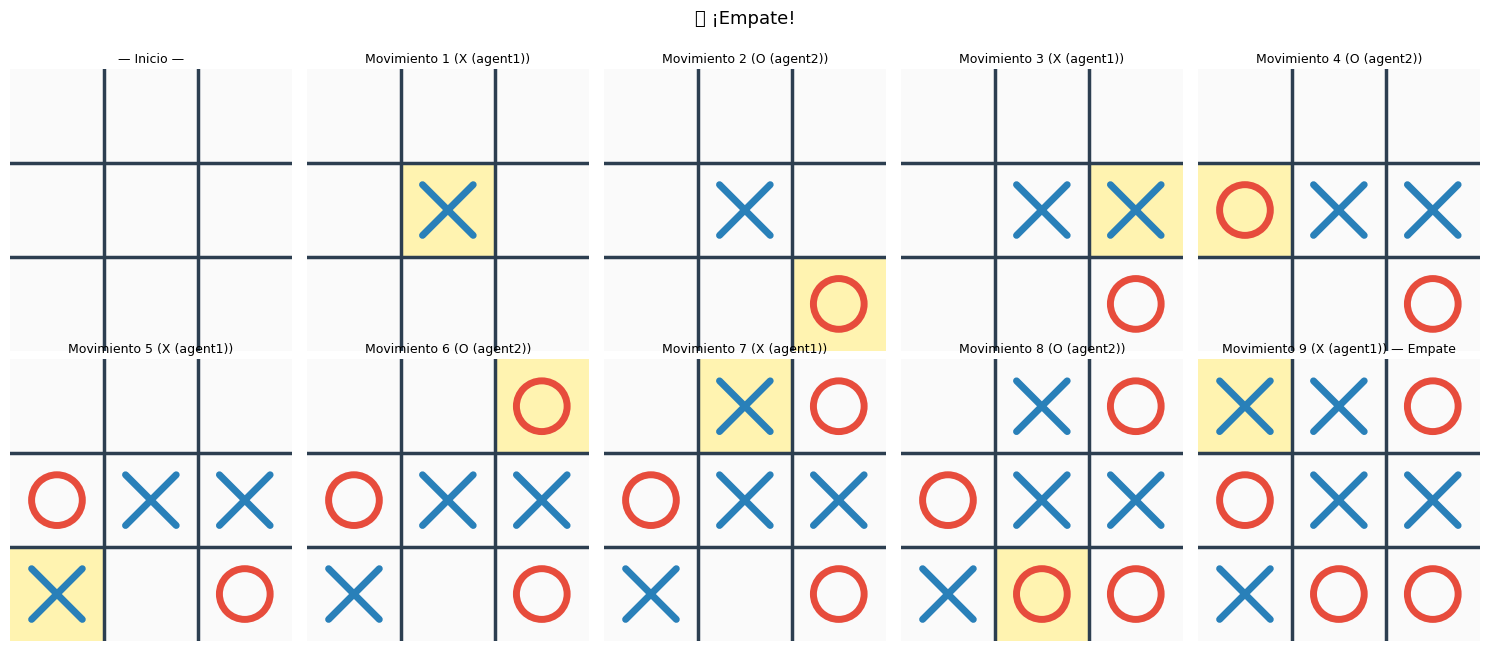

In [ ]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


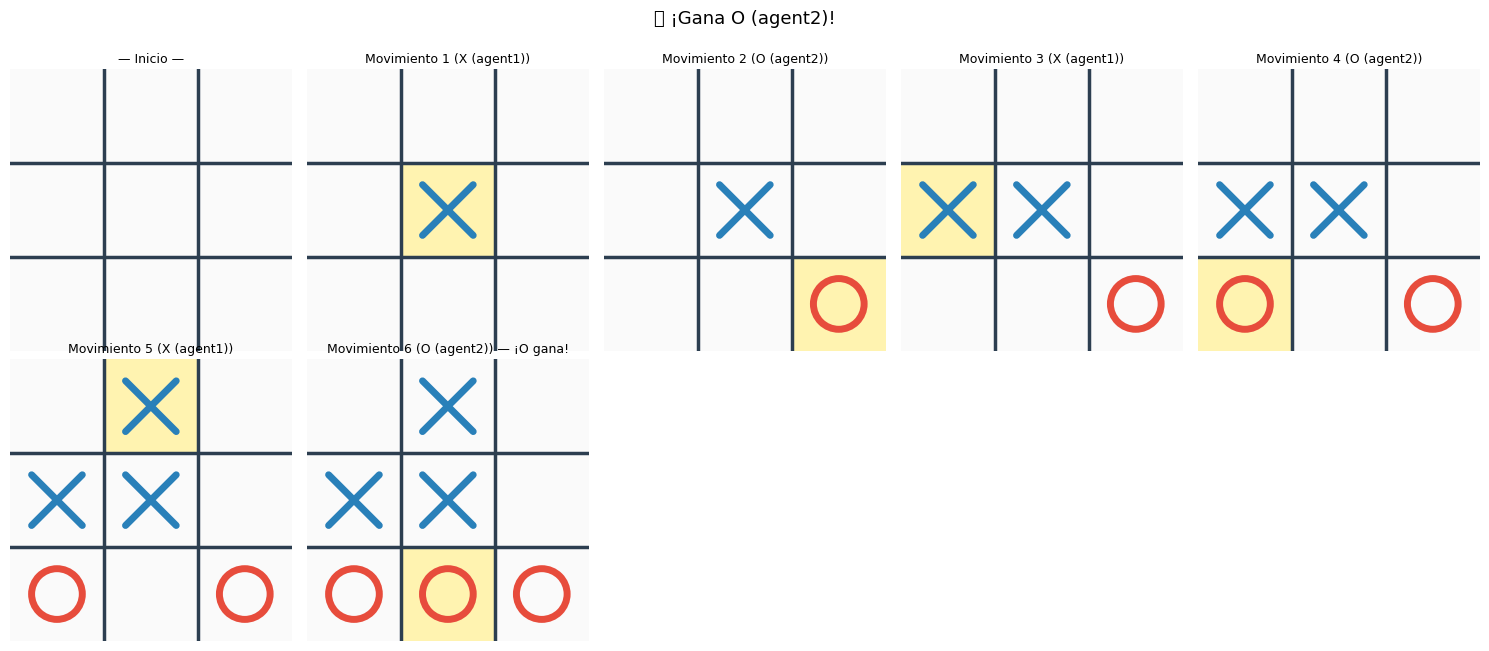

In [80]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=True)

Partida entre agent1 (X) y agent2 (O) — sin exploración:


C:\Users\aaran\AppData\Local\Temp\ipykernel_16124\2326574970.py:64: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


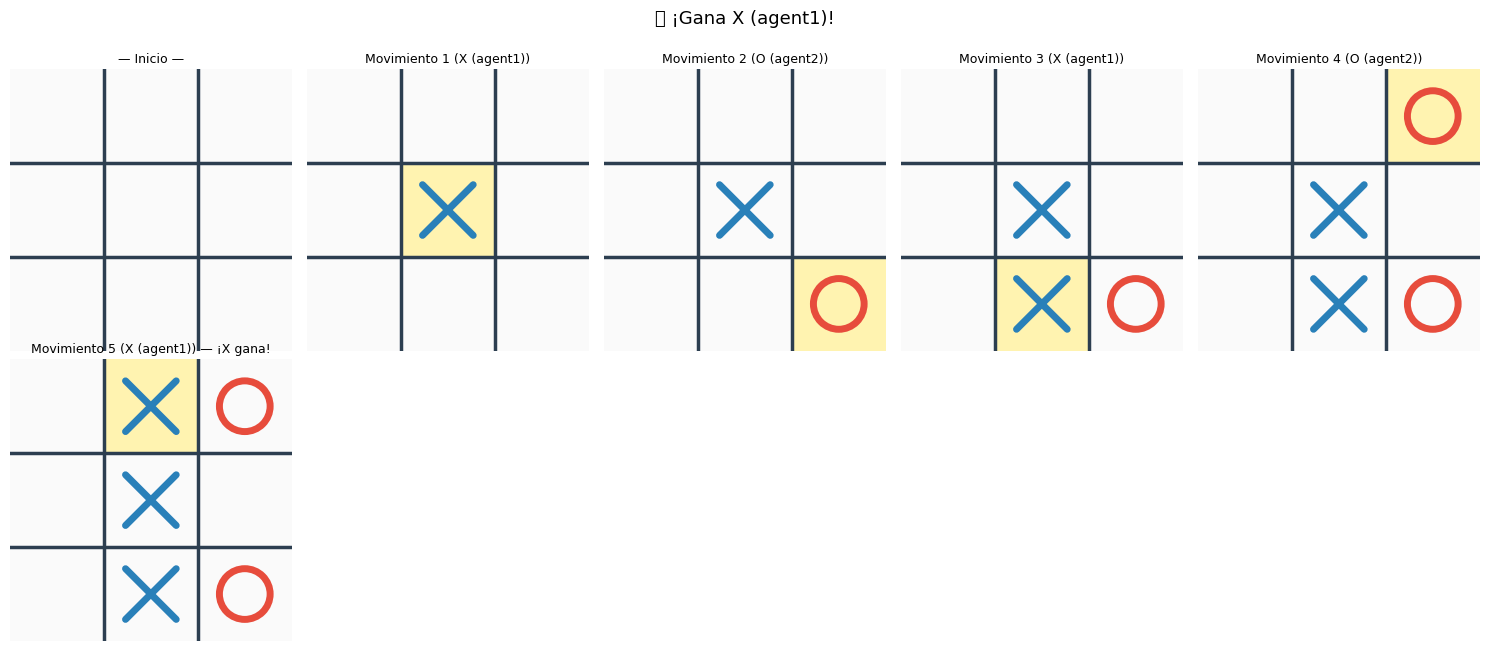

In [79]:
# Partida sin exploración → los agentes usan solo su política aprendida
print("Partida entre agent1 (X) y agent2 (O) — sin exploración:")
resultado = visualizar_partida(agent1, agent2, explore=False)

# SIRVE PARA GUARDAR LOS PARAMETROS DEL ENTRENAMIENTO DEL AGENTE

In [ ]:
import pickle

with open('agente.pickle', 'wb') as handle:
    pickle.dump(agent1.value_function, handle, protocol=pickle.HIGHEST_PROTOCOL)

# SIRVE PARA GUARDAR LOS PARAMETROS DEL ENTRENAMIENTO DEL AGENTE

In [ ]:
import pickle

with open('agente.pickle', 'wb') as handle:
    pickle.dump(agent1.value_function, handle, protocol=pickle.HIGHEST_PROTOCOL)